In [1]:
from pathlib import Path
# import json
# import configparser
import pprint
pp = pprint.PrettyPrinter(indent=4);
import time
import math
from collections import namedtuple

# # pip install slicerio
# import slicerio.server

# # packages for 3d
# #   # for OCT 3D stuff and using in jupyter
# #   - trame-jupyter-extension
# #   - trame
# #   - trame-vtk
# #   - trame-vuetify
# #   - ipywidgets

import matplotlib.pyplot as plt
import plotly.express as px

# interactive panels
import panel as pn
pn.extension('plotly');

import numpy as np
import pandas as pd
import addict

import cv2
import skimage
import sklearn
import scipy.signal

import pyvista as pv
from PIL import Image
import SimpleITK as sitk

import networkx as nx

# with vedo
#from vedo import dataurl, Volume, Text2D
import vedo
vedo.settings.default_backend = 'vtk'
#from vedo.applications import Slicer3DPlotter
import naatos_oct_tools.plotters.vedo_plotters as vedo_plotters
import naatos_oct_tools.plotters.sitk_plotters as sitk_plotters

import naatos_oct_tools.thorlabs_oct_file_reading

In [2]:
# Magics to autoreload submodules when they are modified
%load_ext autoreload
%autoreload 2

In [3]:
# Parameters
oct_scalar_min = 30;
oct_scalar_max = 60;
codename = '20250606';

#study_name = 'GHL_pyapp_20250326T1416'; # strip 14 day 1
#study_name = 'GHL_pyapp_20250327T1450'; # strip 14 day 2
#study_name = 'GHL_pyapp_20250326T1258'; # strip 7 day 1
#study_name = 'GHL_pyapp_20250327T1428'; # strip 7 day 2

#study_name = 'GHL_pyapp_20250505T1514'; # oct study folder
#study_name = 'GHL_pyapp_20250505T1523'; # oct study folder

#study_name = 'GHL_pyapp_20250508T1134'; # oct study folder
#study_name = 'GHL_pyapp_20250508T1539'; # oct study folder
#study_name = 'GHL_pyapp_20250508T1112';
#study_name = 'GHL_pyapp_20250508T1128'; # oct study folder
#study_name = 'GHL_pyapp_20250508T1143'; # oct study folder
#study_name = 'GHL_pyapp_20250512T1204'; # oct study folder

#study_name = 'GHL_pyapp_20250508T1604'; # oct study folder
#study_name = 'GHL_pyapp_20250508T1604'; # oct study folder
#study_name = 'GHL_pyapp_20250508T1612'; # oct study folder
#study_name = 'GHL_pyapp_20250508T1615'; # oct study folder

# 6-6-2025
#study_name = 'GHL_pyapp_20250605T1330'; # oct study folder
#study_name = 'GHL_pyapp_20250605T1422'; # oct study folder
#study_name = 'GHL_pyapp_20250605T1211'; # oct study folder

# 6-11-2025 batches
#study_name = 'GHL_pyapp_20250611T1645';
#study_name = 'GHL_pyapp_20250611T1738';
#study_name = 'GHL_pyapp_20250612T0752'; # initially had bad bounds
#study_name = 'GHL_pyapp_20250612T0734'; # bad bounds

#study_name = 'GHL_pyapp_20250612T0807'; # last step problem
#study_name = 'GHL_pyapp_20250611T1731'; # last step problem
#study_name = 'GHL_pyapp_20250612T0804'; # last step problem

#study_name = 'GHL_pyapp_20250605T1450';
#study_name = 'GHL_pyapp_20250605T1557';
#study_name = 'GHL_pyapp_20250605T1625';

#study_name = 'GHL_WaxRobot_20250711T1513'; # failed early, at 25px
study_name = 'GHL_WaxRobot_20250711T1501'; # failed early, at 825px


# Data Folder (source)
folder_octexport_root = Path(r'\\file.corp.ghlabs.org\Shared\Projects\NAATOS\V1\NAATOS_OCT_WORK\OCTExport')
#folder_octexport_root = r'D:\SGProjects\NAATOS\OCTlocal'

folder_figure_temp = r'D:\\TEMP\\OCTtmp\\';

In [4]:
folder_octexport_root = Path(folder_octexport_root);
folder_figure_temp = Path(folder_figure_temp)/f'{study_name}';

In [5]:
octstudy = naatos_oct_tools.thorlabs_oct_file_reading.OCT_Study_Folder(study_name,folder_octexport_root);

STUDY: GHL_WaxRobot_20250711T1501
{   'study_has_an_ini_file': True,
    'study_has_json_info_file': True,
    'study_has_yat_log': False,
    'study_num_jpg_files': 0,
    'study_num_oct_files': 29,
    'study_num_vtk_files': 0}


In [6]:
octstudy.num_oct_files

29

In [7]:
octstudy

<OCT_Study_Folder Object>
GHL_WaxRobot_20250711T1501 in folder //file.corp.ghlabs.org/Shared/Projects/NAATOS/V1/NAATOS_OCT_WORK/OCTExport
{   'study_has_an_ini_file': True,
    'study_has_json_info_file': True,
    'study_has_yat_log': False,
    'study_num_jpg_files': 0,
    'study_num_oct_files': 29,
    'study_num_vtk_files': 0}

# Read previously-saved Merged volume

In [8]:
fname_merged_and_rescaled_volume = octstudy.folder_study_processed/'{:s}_STACKED_RESCALED_{:}to{:}_uint8.vtk'.format(octstudy.name,oct_scalar_min,oct_scalar_max);
print(f'Loading {fname_merged_and_rescaled_volume.name}')
#vdvol = vedo.read(fname_merged_and_rescaled_volume);
vdvol = vedo.Volume(pv.read(fname_merged_and_rescaled_volume));
octstudy.vdvol = vdvol;
print(vdvol)

Loading GHL_WaxRobot_20250711T1501_STACKED_RESCALED_30to60_uint8.vtk
vedo.volume.Volume at (0x25e589d0730)                                      
name          : Volume
dimensions    : [  690 13050   175]
origin        : (0, 0, 0)
center        : (1.19714, 130.490, 1.74000)
spacing       : (3.47500e-3, 0.0200000, 0.0200000)
bounds        : x=(0, 2.39), y=(0, 261), z=(0, 3.48)
memory size   : 1503 MB
scalar size   : 1 bytes (unsigned char)
scalar range  : (0.0, 255.0)


# Processing Step X - Cast In-Memory Views To SimpleITK Types

In [9]:
# make simpleitk image
import itk
import vtk

def vtkToItk(vtkvol):
    # Get ITK image without requiring new memory

    # create itk_image
    itk_image = itk.image_from_vtk_image(vtkvol)

    # itk_image
    #print(itk_image)
    return itk_image;

def itkToSimpleITK(itk_image):
    new_sitk_image = sitk.GetImageFromArray(itk.GetArrayViewFromImage(itk_image),isVector=itk_image.GetNumberOfComponentsPerPixel()>1);
    new_sitk_image.SetOrigin(tuple(itk_image.GetOrigin()))
    new_sitk_image.SetSpacing(tuple(itk_image.GetSpacing()))
    new_sitk_image.SetDirection(itk.GetArrayFromMatrix(itk_image.GetDirection()).flatten()) 
    return new_sitk_image;
simgmerged = itkToSimpleITK(vtkToItk(vdvol.dataset));

# Prepare To Extract Useful Information

In [10]:
data_extracted = addict.Addict();

# Processing Step 1 - Automatic Find Bounds Of Strip

In [11]:
size = simgmerged.GetSize()
print(simgmerged.GetSize())

(690, 13050, 175)


In [12]:
# Do Binary Threhsolding On Entire Volume Image
step1_binarythresholding_lo = 250;
step1_binarythresholding_hi = 255;
seg = sitk.BinaryThreshold(
    simgmerged, lowerThreshold=step1_binarythresholding_lo, upperThreshold=step1_binarythresholding_hi, insideValue=1, outsideValue=0
)


In [13]:
# Get numpy array view from simpleitk image (shares memory)
print(seg.GetSize())
nda = sitk.GetArrayViewFromImage(seg);
print(nda.shape)
# note the dimensions permute

# sum along each dimension
ndasum0 = nda.sum(axis=0)
ndasum1 = nda.sum(axis=1)
ndasum2 = nda.sum(axis=2)

(690, 13050, 175)
(175, 13050, 690)


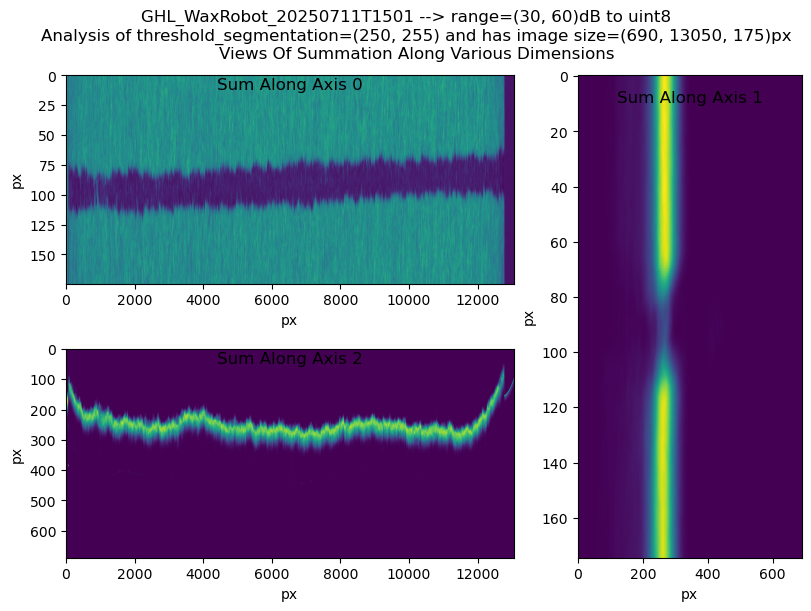

In [14]:
# Show 2d images of summation along each dimension
def mk_analyse_bounds_1():
    fig = plt.figure(figsize=(8,6),constrained_layout=True);
    fig.suptitle(
    """{:s} --> range={:s}dB to uint8
    Analysis of threshold_segmentation={:s} and has image size={:s}px
    Views Of Summation Along Various Dimensions""" \
        .format(
            octstudy.name,
            str((oct_scalar_min,oct_scalar_max)),
            str((step1_binarythresholding_lo,step1_binarythresholding_hi)),
            str(seg.GetSize())
        )
    )
    gs = fig.add_gridspec(2,3);

    fig_ax1 = fig.add_subplot(gs[0,0:2]);
    fig_ax1.set_title('Sum Along Axis 0',y=0.95,verticalalignment='top');
    fig_ax1.imshow(ndasum2,aspect='auto');
    fig_ax1.set_xlabel('px');
    fig_ax1.set_ylabel('px');

    fig_ax2 = fig.add_subplot(gs[:,2]);
    fig_ax2.set_title('Sum Along Axis 1',y=0.95,verticalalignment='top');
    fig_ax2.imshow(ndasum1,aspect='auto');
    fig_ax2.set_xlabel('px');
    fig_ax2.set_ylabel('px');

    fig_ax3 = fig.add_subplot(gs[1,0:2]);
    fig_ax3.set_title('Sum Along Axis 2',y=0.95,verticalalignment='top');
    fig_ax3.imshow(ndasum0.T,aspect='auto');
    fig_ax3.set_xlabel('px');
    fig_ax3.set_ylabel('px');

    return fig;
fig = mk_analyse_bounds_1();
#fig.savefig(octstudy.folder_study_processed/'processing_step1a_{:s}.jpg'.format(time.strftime('%Y%m%d')))
fig.savefig(octstudy.folder_study_processed/'processing_step1a.jpg'.format(time.strftime('%Y%m%d')))

shape (175, 13050)
threshold_value_lo 3221.0
threshold_value_hi 6987.25
threshold_value_lo2 7.083037512821067
threshold_value_hi2 16.169863006084498


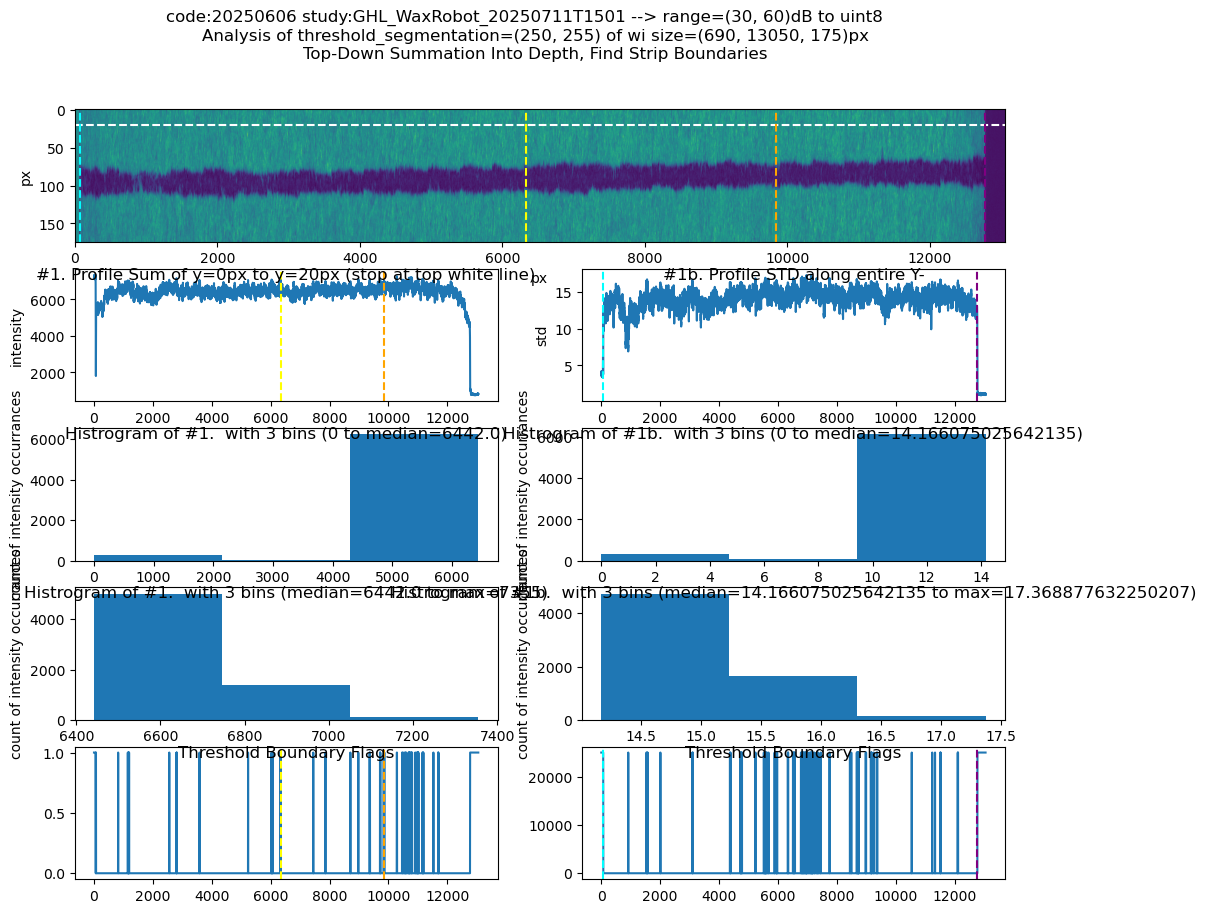

In [15]:
# Do Automatic Analysis Using Line At First Quarter Of Strip
def mk_analyse_bounds_2():
    #fig,ax = plt.subplots(5,1,figsize=(12,10),squeeze=False);
    fig = plt.figure(figsize=(12,10));
    gs = fig.add_gridspec(5,2);
    fig.suptitle(
    """code:{:s} study:{:s} --> range={:s}dB to uint8
    Analysis of threshold_segmentation={:s} of wi size={:s}px
    Top-Down Summation Into Depth, Find Strip Boundaries""" \
        .format(
            codename,
            octstudy.name,
            str((oct_scalar_min,oct_scalar_max)),
            str((step1_binarythresholding_lo,step1_binarythresholding_hi)),
            str(seg.GetSize())
        )
    )

    ndasum2 = nda.sum(axis=2);

    #ycutlocation = ndasum2.shape[0]//2;
    ycutlocation = 20;
    ycutlocation2 = ndasum2.shape[0]-ycutlocation;

    print('shape',ndasum2.shape)
    
    ax = fig.add_subplot(gs[0,0:2]);
    ax_top = ax;
    ax.imshow(ndasum2,aspect='auto');
    ax.axhline(ycutlocation,color='white',linestyle='dashed')
    #ax.axhline(ycutlocation2,color='white',linestyle='dashed')
    ax.set_xlabel('px')
    ax.set_ylabel('px')

    ax = fig.add_subplot(gs[1,0]);
    ax_10 = ax;
    ax.set_title('#1. Profile Sum of y=0px to y={:}px (stop at top white line)'.format(ycutlocation),y=0.95,verticalalignment='top')
    #a_whiteline = ndasum2[0:ycutlocation,:].copy();
    a_whiteline = ndasum2.copy();
    a_whiteline = a_whiteline.sum(axis=0);
    ax.plot(a_whiteline);
    ax.set_xlabel('px')
    ax.set_ylabel('intensity')

    # bin histogram along white line, into 3 bins, with the median being the upper range
    median = np.median(a_whiteline)
    ax = fig.add_subplot(gs[2,0]);
    ax_20 = ax;
    ax.set_title('Histrogram of #1.  with 3 bins (0 to median={:})'.format(median),y=0.95,verticalalignment='top')
    histret,histedges,_ = ax.hist(a_whiteline,bins=3,range=(0,median))
    ax.set_xlabel('bin')
    ax.set_ylabel('count of intensity occurrances')

    ax = fig.add_subplot(gs[3,0]);
    ax_30 = ax;
    ax.set_title('Histrogram of #1.  with 3 bins (median={:} to max={:})'.format(median,np.max(a_whiteline)),y=0.95,verticalalignment='top')
    histret2,histedges2,_ = ax.hist(a_whiteline,bins=3,range=(median,np.max(a_whiteline)))
    ax.set_xlabel('bin')
    ax.set_ylabel('count of intensity occurrances')

    # histogram analysis
    #hist_max_bin = np.argmax(histret); # bin that is tallest
    #hist_median_bin = np.argmin(abs(median-histedges)); # bin where the median lies

    # low-swinging threshold
    # take the value left of the median bin
    #threshold_value_lo = (histedges[hist_median_bin-1]);
    threshold_value_lo = (histedges[2]+histedges[1])/2;
    # Corner Case Check
    # check the right-side of the strip to see if the threshold_value_lo is higher than the min
    #threshold_value_lo = 
    if(a_whiteline[ndasum2.shape[1]-ndasum2.shape[1]//4:].min()>threshold_value_lo):
        # pick a new threshold_value_lo
        threshold_value_lo = histedges[2]
        pass;
    print('threshold_value_lo',threshold_value_lo);

    # high-swinging threshold
    # take the value right of the median bin
    #threshold_value_hi = (histedges[hist_median_bin+1]);
    threshold_value_hi = 1.3*(histedges2[1]+histedges2[0])/2;
    if(threshold_value_hi>np.max(a_whiteline)):
        threshold_value_hi = np.max(a_whiteline)*0.95;
    print('threshold_value_hi',threshold_value_hi);

    # look for sharp edges transitioning where these bins occur
    #a_whiteline[...]=0;
    a_whiteline[(a_whiteline>=threshold_value_hi) | (a_whiteline<=threshold_value_lo)] = 1
    a_whiteline[(a_whiteline<threshold_value_hi) & (a_whiteline>threshold_value_lo)] = 0
    #a_whiteline[(a_whiteline>=threshold_value_hi)] = 1
    ax = fig.add_subplot(gs[4,0]);
    ax_bot1 = ax;
    ax.plot(a_whiteline)
    ax.set_title('Threshold Boundary Flags',y=0.95,verticalalignment='top')
    transition_edges = np.where(a_whiteline[:-1] != a_whiteline[1:])[0]
    # for right edge, start at middle and find right-most
    #edge_right = transition_edges[transition_edges>(ndasum2.shape[1]//2)][0];
    edge_right = transition_edges[transition_edges>(ndasum2.shape[1]-ndasum2.shape[1]//4)][0]; # right-most quarter
    idx = transition_edges<=(ndasum2.shape[1]//2);
    if(idx.any()):
        edge_left = transition_edges[transition_edges<=(ndasum2.shape[1]//2)][-1];
    else:
        # TODO
        pass;

    ax_top.axvline(edge_left,color='yellow',linestyle='dashed')
    ax_top.axvline(edge_right,color='orange',linestyle='dashed')
    ax_10.axvline(edge_left,color='yellow',linestyle='dashed')
    ax_10.axvline(edge_right,color='orange',linestyle='dashed')
    ax_bot1.axvline(edge_left,color='yellow',linestyle='dashed')
    ax_bot1.axvline(edge_right,color='orange',linestyle='dashed')



    #--- now examine the white bottom line segment
    ax = fig.add_subplot(gs[1,1]);
    ax_11 = ax;
    ax.set_title('#1b. Profile STD along entire Y-',y=0.95,verticalalignment='top')
    #a_whiteline = ndasum2[0:ycutlocation,:].copy();
    a_whiteline2 = ndasum2.copy();
    a_whiteline2 = a_whiteline2.std(axis=0);
    ax.plot(a_whiteline2);
    ax.set_xlabel('px')
    ax.set_ylabel('std')

    # bin histogram along white line, into 3 bins, with the median being the upper range
    median2 = np.median(a_whiteline2);
    ax = fig.add_subplot(gs[2,1]);
    ax_21 = ax;
    ax.set_title('Histrogram of #1b.  with 3 bins (0 to median={:})'.format(median2),y=0.95,verticalalignment='top');
    histretb,histedgesb,_ = ax.hist(a_whiteline2,bins=3,range=(0,median2));
    ax.set_xlabel('bin');
    ax.set_ylabel('count of intensity occurrances');

    ax = fig.add_subplot(gs[3,1]);
    ax_31 = ax;
    ax.set_title('Histrogram of #1b.  with 3 bins (median={:} to max={:})'.format(median2,np.max(a_whiteline2)),y=0.95,verticalalignment='top');
    histret2b,histedges2b,_ = ax.hist(a_whiteline2,bins=3,range=(median2,np.max(a_whiteline2)));
    ax.set_xlabel('bin');
    ax.set_ylabel('count of intensity occurrances');

    # low-swinging threshold
    # take the value left of the median bin
    #threshold_value_lo = (histedges[hist_median_bin-1]);
    threshold_value_lo2 = (histedgesb[2]+histedgesb[1])/2;
    print('threshold_value_lo2',threshold_value_lo2);

    # high-swinging threshold
    # take the value right of the median bin
    #threshold_value_hi = (histedges[hist_median_bin+1]);
    threshold_value_hi2 = 1.1*(histedges2b[1]+histedges2b[0])/2;
    print('threshold_value_hi2',threshold_value_hi2);

    # look for sharp edges transitioning where these bins occur
    #a_whiteline[...]=0;
    a_whiteline2[(a_whiteline2>=threshold_value_hi2) | (a_whiteline2<=threshold_value_lo2)] = 25000
    #a_whiteline2[(a_whiteline2>=threshold_value_hi2)] = 25000
    a_whiteline2[(a_whiteline2<threshold_value_hi2) & (a_whiteline2>threshold_value_lo2)] = 0
    #a_whiteline[(a_whiteline>=threshold_value_hi)] = 1
    ax = fig.add_subplot(gs[4,1]);
    ax_bot2 = ax;
    ax.plot(a_whiteline2)
    ax.set_title('Threshold Boundary Flags',y=0.95,verticalalignment='top')
    transition_edges = np.where(a_whiteline2[:-1] != a_whiteline2[1:])[0]
    # for right edge, start at middle and find right-most
    #edge_right = transition_edges[transition_edges>(ndasum2.shape[1]//2)][0];
    # edge_right2 = transition_edges[transition_edges>(ndasum2.shape[1]-ndasum2.shape[1]//8)][0]; # right-most eigth
    # edge_left2 = transition_edges[transition_edges<=(ndasum2.shape[1]//8)][-1]; # left-most eighth
    edge_right2 = transition_edges[transition_edges>(ndasum2.shape[1]-1000)][-1]; # right-most 1000 pixels
    edge_left2 = transition_edges[transition_edges<=(1000)][0]; # left-most 1000 pixels
    
    #edge_right2 = a_whiteline2[a_whiteline2>(ndasum2.shape[1]-ndasum2.shape[1]//4)][0]; # right-most quarter


    ax_top.axvline(edge_left2,color='cyan',linestyle='dashed')
    ax_top.axvline(edge_right2,color='purple',linestyle='dashed')
    ax_11.axvline(edge_left2,color='cyan',linestyle='dashed')
    ax_11.axvline(edge_right2,color='purple',linestyle='dashed')
    ax_bot2.axvline(edge_left2,color='cyan',linestyle='dashed')
    ax_bot2.axvline(edge_right2,color='purple',linestyle='dashed')



    # store useful information
    data_extracted['auto_bounds']['topdown_edge_left_px'] = edge_left2.item();
    data_extracted['auto_bounds']['topdown_edge_right_px'] = edge_right2.item();

    return fig;
fig = mk_analyse_bounds_2();

# save figure
#fig.savefig(octstudy.folder_study_processed/'processing_step1b_{:s}.jpg'.format(time.strftime('%Y%m%d')))
fig.savefig(octstudy.folder_study_processed/'processing_step1b.jpg'.format(time.strftime('%Y%m%d')))

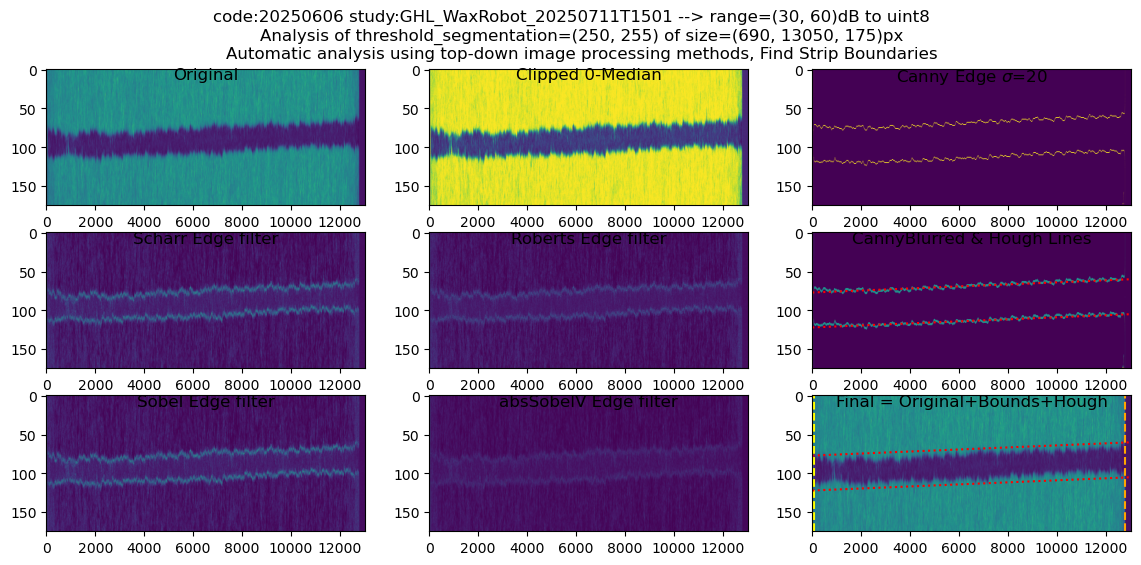

In [16]:
# Do automatic analysis using top-down image processing methods
def mk_analyse_bounds_3():
    fig,ax = plt.subplots(3,3,figsize=(14,6),squeeze=False);

    fig.suptitle(
    """code:{:s} study:{:s} --> range={:s}dB to uint8
    Analysis of threshold_segmentation={:s} of size={:s}px
    Automatic analysis using top-down image processing methods, Find Strip Boundaries""" \
        .format(
            codename,
            octstudy.name,
            str((oct_scalar_min,oct_scalar_max)),
            str((step1_binarythresholding_lo,step1_binarythresholding_hi)),
            str(seg.GetSize())
        )
    )

    #image = ndasum2[:,edge_left:edge_right];
    image = ndasum2

    ax[0,0].set_title('Original',y=0.95,verticalalignment='top')
    ax[0,0].imshow(image,aspect='auto')

    ax[0,1].set_title('Clipped 0-Median',y=0.95,verticalalignment='top')
    median = np.median(image);
    image2 = np.clip(image,a_min=0,a_max=median);
    ax[0,1].imshow(image2,aspect='auto')

    ax[1,0].set_title('Scharr Edge filter',y=0.95,verticalalignment='top')
    edge_scharr = skimage.filters.scharr(image2);
    ax[1,0].imshow(edge_scharr,aspect='auto')

    ax[1,1].set_title('Roberts Edge filter',y=0.95,verticalalignment='top')
    edge_roberts = skimage.filters.roberts(image2);
    ax[1,1].imshow(edge_roberts,aspect='auto')

    ax[2,0].set_title('Sobel Edge filter',y=0.95,verticalalignment='top')
    edge_sobel = skimage.filters.sobel(image2);
    ax[2,0].imshow(edge_sobel,aspect='auto')

    ax[2,1].set_title('absSobelV Edge filter',y=0.95,verticalalignment='top')
    edge_sobelv = skimage.filters.sobel_v(image2);
    ax[2,1].imshow(abs(edge_sobelv),aspect='auto')

    ax[0,2].set_title(r'Canny Edge $\sigma$=20',y=0.95,verticalalignment='top')
    edge_canny = skimage.feature.canny(image2,sigma=20,low_threshold=0.45,high_threshold=0.55)
    ax[0,2].imshow(edge_canny.view(dtype=np.uint8),aspect='auto')


    # contours = skimage.measure.find_contours(edge_canny.view(dtype=np.uint8),level=0.5)
    # for contour in contours:
    #     ax[1,2].plot(contour[:, 1], contour[:, 0], linewidth=2)
    # ax[1,2].yaxis.set_inverted(True)

    # -- find some boundaries on topdown view using image processing methods
    # houghline finding
    ax[1,2].set_title(r'CannyBlurred & Hough Lines',y=0.95,verticalalignment='top')
    img_blured_edges = cv2.blur(edge_canny.view(dtype=np.uint8)*255,(3,3));
    ax[1,2].imshow(img_blured_edges,aspect='auto')

    # Straight-line Hough transform
    # Set a precision of Scan a 10 degree angle off the normal (this seems to be 90 degrees with this skimage implementation for horizontal-like lines) with resolution of 0.05 degrees.
    tested_angles = np.linspace(math.radians(90-10),math.radians(90+10),int( (math.radians(10)*2)/math.radians(0.05) ), endpoint=True)
    h, theta, d = skimage.transform.hough_line(img_blured_edges, theta=tested_angles)
    hough_line_data = skimage.transform.hough_line_peaks(h, theta, d);
    for _, angle, dist in zip(*hough_line_data):
        (x0, y0) = dist * np.array([np.cos(angle), np.sin(angle)])
        ax[1,2].axline((x0, y0), slope=np.tan(angle + np.pi / 2), color='red',linestyle='dotted')

    if False:
        # Straight-line Hough transform
        # Set a precision of Scan a 10 degree angle off the normal (this seems to be 90 degrees with this skimage implementation for horizontal-like lines) with resolution of 0.05 degrees.
        tested_angles = np.linspace(math.radians(0-10),math.radians(0+10),int( (math.radians(10)*2)/math.radians(0.05) ), endpoint=True)
        h, theta, d = skimage.transform.hough_line(img_blured_edges, theta=tested_angles)
        hough_line_data2 = skimage.transform.hough_line_peaks(h, theta, d);
        for _, angle, dist in zip(*hough_line_data2):
            (x0, y0) = dist * np.array([np.cos(angle), np.sin(angle)])
            ax[1,2].axline((x0, y0), slope=np.tan(angle + np.pi / 2), color='blue',linestyle='dotted')

    if False:
        # Calculate a boundary from sum along strip width
        along_strip_sum=ndasum2.sum(axis=0);
        along_strip_sum_derivative = scipy.signal.savgol_filter(along_strip_sum,window_length=32,polyorder=3,deriv=1)
        edge_topdown_left2 = np.argmax(along_strip_sum_derivative).item();
        edge_topdown_right2 = np.argmin(along_strip_sum_derivative).item();
    if True:
        edge_topdown_left2 = data_extracted['auto_bounds']['topdown_edge_left_px'];
        edge_topdown_right2 = data_extracted['auto_bounds']['topdown_edge_right_px'];

    # were these opposites? swap them if so
    if(edge_topdown_left2>edge_topdown_right2):
        edge_topdown_left2,edge_topdown_right2 = (edge_topdown_right2,edge_topdown_left2);
    ax[2,2].set_title(r'Final = Original+Bounds+Hough',y=0.95,verticalalignment='top')
    ax[2,2].imshow(image,aspect='auto');
    ax[2,2].axvline(edge_topdown_left2,color='yellow',linestyle='--')
    ax[2,2].axvline(edge_topdown_right2,color='orange',linestyle='--')
    for _, angle, dist in zip(*hough_line_data):
        (x0, y0) = dist * np.array([np.cos(angle), np.sin(angle)])
        ax[2,2].axline((x0, y0), slope=np.tan(angle + np.pi / 2), color='red',linestyle='dotted')

    # Extract relevant data
    data_extracted['auto_bounds']['topdown_edge_left_px2'] = edge_topdown_left2+5; # move in just a bit
    data_extracted['auto_bounds']['topdown_edge_right_px2'] = edge_topdown_right2-5; # move in just a bit
    data_extracted['auto_topdown_houghline'] = hough_line_data;

    return fig;
fig = mk_analyse_bounds_3();
# Save to processed folder
#fig.savefig(octstudy.folder_study_processed/'processing_step1c_{:s}.jpg'.format(time.strftime('%Y%m%d')))
fig.savefig(octstudy.folder_study_processed/'processing_step1c.jpg'.format(time.strftime('%Y%m%d')))

Left Median  7945016.0
Left Curve Crosses Median @  123
Left First Zerocross 6
histogram of ndasum (array([ 10, 204,  98, 188]), array([7635516., 7814139., 7992762., 8171385., 8350008.]))
goes below threhsold at 274
MedianRatioMin 1.0510942547956157
MedianRatioMax 0.9611544084748183
Median-Min= 390131.0
Max-Median= 324361.0
Range= 714492
2,1 Right Peaks: (array([], dtype=int64), {'prominences': array([], dtype=float64), 'left_bases': array([], dtype=int64), 'right_bases': array([], dtype=int64)})


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


{   'auto_bounds': {   'topdown_edge_left_px': 66,
                       'topdown_edge_left_px2': 71,
                       'topdown_edge_left_px3': np.int64(194),
                       'topdown_edge_right_px': 12770,
                       'topdown_edge_right_px2': 12765,
                       'topdown_edge_right_px3': 12765},
    'auto_topdown_houghline': (   array([7093, 7022], dtype=uint64),
                                  array([1.56948405, 1.56948405]),
                                  array([122.,  77.]))}


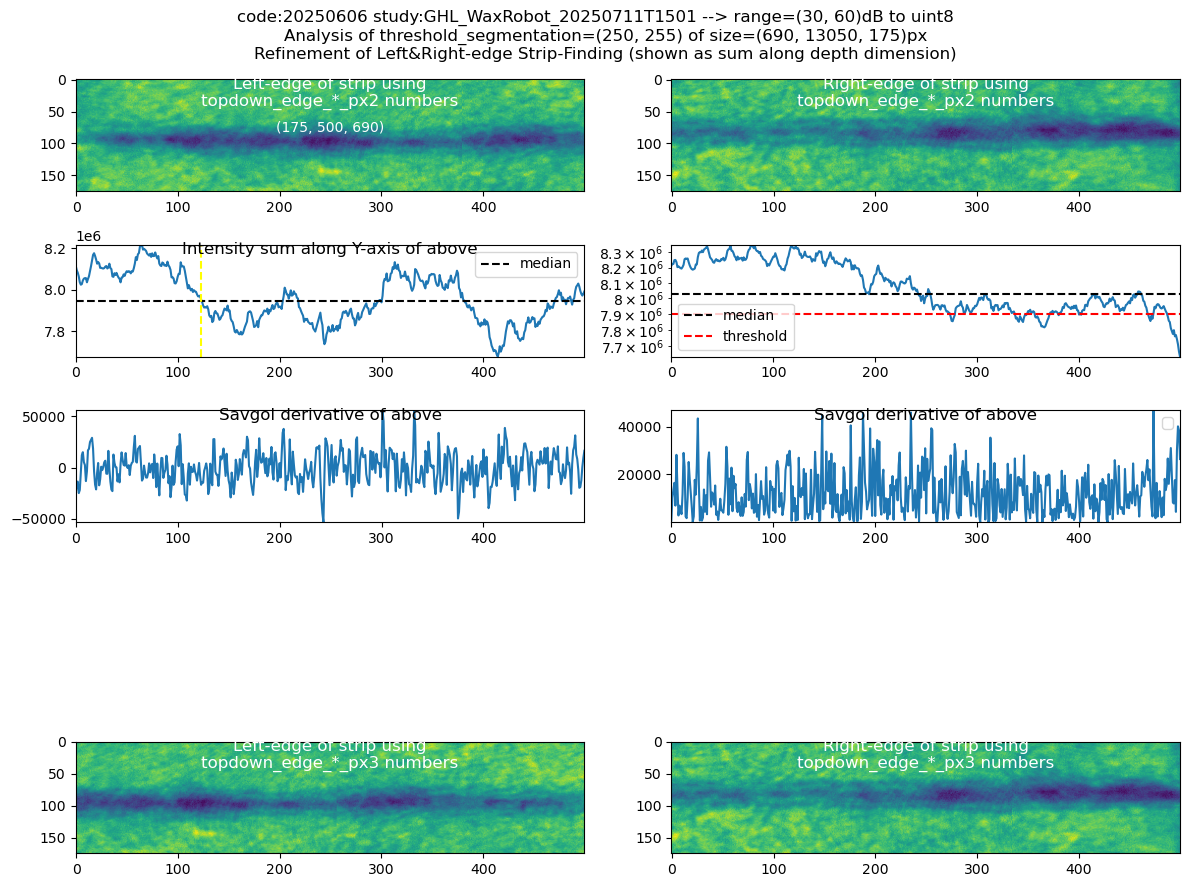

In [17]:
# Refine left/right edge finding
# Do automatic analysis, bounds checking
def mk_analyse_bounds_4(window_width = 500):
    fig = plt.figure(figsize=(12,9));
    gs = fig.add_gridspec(5,2);

    fig.suptitle(
    """code:{:s} study:{:s} --> range={:s}dB to uint8
    Analysis of threshold_segmentation={:s} of size={:s}px
    Refinement of Left&Right-edge Strip-Finding (shown as sum along depth dimension)""" \
        .format(
            codename,
            octstudy.name,
            str((oct_scalar_min,oct_scalar_max)),
            str((step1_binarythresholding_lo,step1_binarythresholding_hi)),
            str(seg.GetSize())
        )
    )

    # Plot topdown_edge_*_px2 left edges up close
    ax = fig.add_subplot(gs[0,0]);
    tmpimg = simgmerged[:,   data_extracted['auto_bounds']['topdown_edge_left_px2']:data_extracted['auto_bounds']['topdown_edge_left_px2']+window_width , : ]
    nda = sitk.GetArrayViewFromImage(tmpimg)
    ndasum = np.sum(nda,axis=2);
    ax.imshow(ndasum,aspect='auto')
    ax.set_title('Left-edge of strip using\ntopdown_edge_*_px2 numbers',y=0.95,verticalalignment='top',color='white');
    ax.text(s='{:}'.format(str(nda.shape)),
            x=0.5,y=0.5,
            horizontalalignment='center',verticalalignment='bottom',
            color='white',transform=ax.transAxes
    );

    ax = fig.add_subplot(gs[1,0]);
    ax.set_title('Intensity sum along Y-axis of above',y=0.95,verticalalignment='top',color='black');
    ndasum_curve = np.sum(ndasum,axis=0);
    median = np.median(ndasum_curve);
    print('Left Median ',median)
    ax.plot(ndasum_curve)
    ax.axhline(median,label='median',color='black',linestyle='dashed')
    ax.legend(loc='best')
    ax.autoscale(enable=True, axis='both', tight=True)
    mask_c = np.logical_or(
      np.logical_or((ndasum_curve < median)*(np.roll(ndasum_curve, -1) > median), 
                    (ndasum_curve > median)*(np.roll(ndasum_curve, -1) < median)),
      ndasum_curve == median)
    #print('Left MaskC',mask_c);
    left_ndasum_curve_crosses_median_initially = np.where(mask_c)[0][0]; # first crossing on left side
    print('Left Curve Crosses Median @ ',left_ndasum_curve_crosses_median_initially);
    ax.axvline(left_ndasum_curve_crosses_median_initially,label='leftcrossesmedian',color='yellow',linestyle='dashed')

    ax = fig.add_subplot(gs[2,0]);
    ax.set_title('Savgol derivative of above',y=0.95,verticalalignment='top',color='black');
    ndasum_curve_savgol1 = scipy.signal.savgol_filter(ndasum_curve,window_length=5,polyorder=3,deriv=1);
    ax.plot(ndasum_curve_savgol1)
    left_firstzerocross = 0;
    if(ndasum_curve_savgol1[0]<0):
        # start traversing to the right, look for where we cross zero
        #print(np.where(ndasum_curve_savgol1>0))
        left_firstzerocross = np.where(ndasum_curve_savgol1>0)[0][0];
    else:
        # start traversing to the right, we were up,
        left_firstzerocross = np.where(ndasum_curve_savgol1<0)[0][0];
    if(left_firstzerocross>0):
        print('Left First Zerocross',left_firstzerocross)
        #ax.axvline(left_firstzerocross,label='firstzerocross',color='yellow',linestyle='dashed')
    ax.autoscale(enable=True, axis='both', tight=True)


    # Plot topdown_edge_*_px2 right edges up close
    ax = fig.add_subplot(gs[0,1]);
    tmpimg = simgmerged[:,   data_extracted['auto_bounds']['topdown_edge_right_px2']-window_width:data_extracted['auto_bounds']['topdown_edge_right_px2'] , : ]
    nda = sitk.GetArrayViewFromImage(tmpimg)
    ndasum = np.sum(nda,axis=2);
    ax.imshow(ndasum,aspect='auto')
    ax.set_title('Right-edge of strip using\ntopdown_edge_*_px2 numbers',y=0.95,verticalalignment='top',color='white');

    
    
    ax = fig.add_subplot(gs[1,1]);
    #tmpimg = simgmerged[:,   data_extracted['auto_bounds']['topdown_edge_right_px2']-500:data_extracted['auto_bounds']['topdown_edge_right_px2'] , : ]
    #nda = sitk.GetArrayViewFromImage(tmpimg)
    ndasum_curve = np.sum(ndasum,axis=0);
    ax.semilogy(ndasum_curve);
    median = np.median(ndasum_curve);
    hist = np.histogram(ndasum_curve,bins=4)
    print('histogram of ndasum',hist)
    # pick 2nd to last bin edge for thresholding
    #threshold = hist[1][2]
    threshold = (hist[1][2]-hist[1][1])/2+hist[1][1]
    #threshold = hist[1][1]
    #threshold = skimage.filters.threshold_minimum(ndasum.copy().astype(float))
    firstcrossingbelowthreshold = np.argmax(ndasum_curve<threshold).item()
    print('goes below threhsold at',firstcrossingbelowthreshold)
    ax.axhline(median,label='median',color='black',linestyle='dashed')
    ax.axhline(threshold,label='threshold',color='red',linestyle='dashed')
    # is the median very close to the max and the min??
    minmediandistance = median-np.min(ndasum_curve);
    maxmediandistance = np.max(ndasum_curve)-median
    curverange = np.max(ndasum_curve)-np.min(ndasum_curve);
    medianpercentmin = median/np.min(ndasum_curve);
    medianpercentmax = median/np.max(ndasum_curve);
    print('MedianRatioMin',medianpercentmin);
    print('MedianRatioMax',medianpercentmax);
    print('Median-Min=',minmediandistance);
    print('Max-Median=',maxmediandistance);
    print('Range=',curverange)
    if(firstcrossingbelowthreshold==0 or ((medianpercentmin< 1.15) and (medianpercentmax>0.75))):
        firstcrossingbelowthreshold = window_width;
    else:
        ax.axvline(firstcrossingbelowthreshold,label='refined right-edge position (abandoned)',color='orange',linestyle='dashed');
    ax.legend(loc='best')
    ax.autoscale(enable=True, axis='both', tight=True)

    if False:
        data_extracted['auto_bounds']['topdown_edge_right_px3'] = data_extracted['auto_bounds']['topdown_edge_right_px2']-(window_width-firstcrossingbelowthreshold);

    ax = fig.add_subplot(gs[2,1]);
    ax.set_title('Savgol derivative of above',y=0.95,verticalalignment='top',color='black');
    ndasum_curve_savgol2 = scipy.signal.savgol_filter(ndasum_curve,window_length=5,polyorder=3,deriv=1);
    ax.plot(abs(ndasum_curve_savgol2))
    pks = scipy.signal.find_peaks(abs(ndasum_curve_savgol2),prominence=100000,wlen=10);
    print('2,1 Right Peaks:',pks)
    ax.plot(pks[0],abs(ndasum_curve_savgol2)[pks[0]],marker='.',linestyle='none')
    # left_firstzerocross = 0;
    # if(ndasum_curve_savgol2[0]<0):
    #     # start traversing to the right, look for where we cross zero
    #     #print(np.where(ndasum_curve_savgol1>0))
    #     left_firstzerocross = np.where(ndasum_curve_savgol1>0)[0][0];
    # else:
    #     # start traversing to the right, we were up,
    #     left_firstzerocross = np.where(ndasum_curve_savgol1<0)[0][0];
    # if(left_firstzerocross>0):
    #     print('Left First Zerocross',left_firstzerocross)
    #     #ax.axvline(left_firstzerocross,label='firstzerocross',color='yellow',linestyle='dashed')
    ax.autoscale(enable=True, axis='both', tight=True)
    if True:
        #data_extracted['auto_bounds']['topdown_edge_right_px3'] = data_extracted['auto_bounds']['topdown_edge_right_px2']-(window_width-firstcrossingbelowthreshold);
        if(len(pks[1]['left_bases'])>0):
            ax.axvline(pks[1]['left_bases'][-1],label='refined right edge px3',color='red',linestyle='dashed');
            refined_right_edge_px3_frompks = pks[1]['left_bases'][-1];
            data_extracted['auto_bounds']['topdown_edge_right_px3'] = data_extracted['auto_bounds']['topdown_edge_right_px2']-(window_width- refined_right_edge_px3_frompks);
        else:
            # fallback method
            data_extracted['auto_bounds']['topdown_edge_right_px3'] = data_extracted['auto_bounds']['topdown_edge_right_px2']-(window_width-firstcrossingbelowthreshold);
        ax.legend(loc='best');

        #data_extracted['auto_bounds']['topdown_edge_right_px3'] = data_extracted['auto_bounds']['topdown_edge_right_px2']-(window_width- refined_right_edge_px3_frompks);



    #data_extracted['auto_bounds']['topdown_edge_left_px3'] = data_extracted['auto_bounds']['topdown_edge_left_px2']
    # if(left_firstzerocross is not 0):
    #     data_extracted['auto_bounds']['topdown_edge_left_px3'] = data_extracted['auto_bounds']['topdown_edge_left_px2']
    # else:
    #     data_extracted['auto_bounds']['topdown_edge_left_px3'] = data_extracted['auto_bounds']['topdown_edge_left_px2']-(window_width-left_firstzerocross)
    #data_extracted['auto_bounds']['topdown_edge_left_px3'] = data_extracted['auto_bounds']['topdown_edge_left_px2']+(left_firstzerocross.item());
    data_extracted['auto_bounds']['topdown_edge_left_px3'] = data_extracted['auto_bounds']['topdown_edge_left_px2']+left_ndasum_curve_crosses_median_initially;
    
    # take a closer look at the left edge

   
    
    ax = fig.add_subplot(gs[4,1]);
    tmpimg = simgmerged[:,   data_extracted['auto_bounds']['topdown_edge_right_px3']-window_width:data_extracted['auto_bounds']['topdown_edge_right_px3'] , : ]
    nda = sitk.GetArrayViewFromImage(tmpimg)
    ndasum = np.sum(nda,axis=2);
    ax.imshow(ndasum,aspect='auto')
    ax.set_title('Right-edge of strip using\ntopdown_edge_*_px3 numbers',y=0.95,verticalalignment='top',color='white');


    ax = fig.add_subplot(gs[4,0]);
    tmpimg = simgmerged[:,   data_extracted['auto_bounds']['topdown_edge_left_px3']:data_extracted['auto_bounds']['topdown_edge_left_px3']+window_width , : ]
    nda = sitk.GetArrayViewFromImage(tmpimg)
    ndasum = np.sum(nda,axis=2);
    ax.imshow(ndasum,aspect='auto')
    ax.set_title('Left-edge of strip using\ntopdown_edge_*_px3 numbers',y=0.95,verticalalignment='top',color='white');

    pp.pprint(data_extracted)

    fig.tight_layout();

    return fig;
fig = mk_analyse_bounds_4();
#fig.savefig(octstudy.folder_study_processed/'processing_step1d_{:s}.jpg'.format(time.strftime('%Y%m%d')))
fig.savefig(octstudy.folder_study_processed/'processing_step1d.jpg'.format(time.strftime('%Y%m%d')))

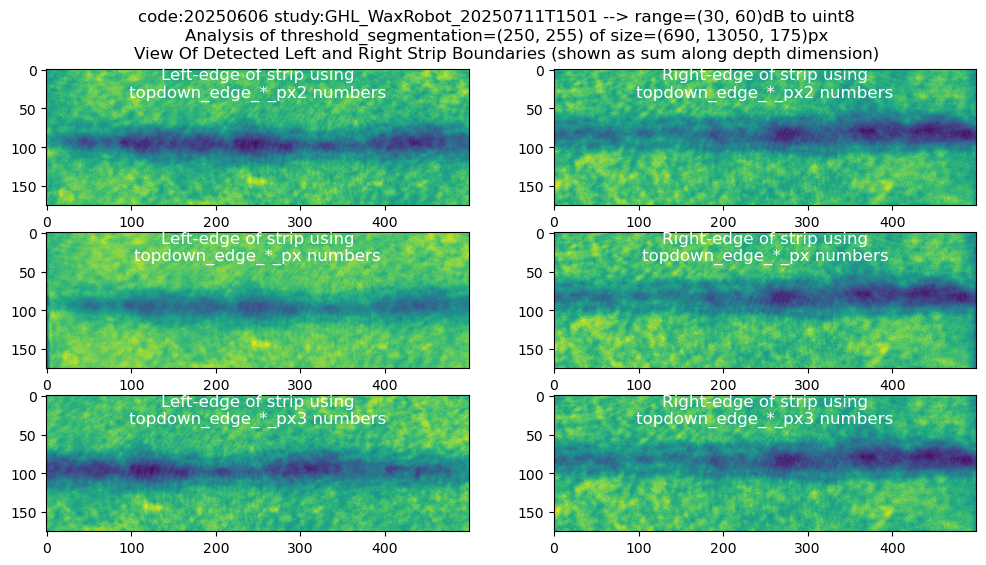

In [18]:
# Do automatic analysis, bounds checking
def mk_analyse_bounds_5(window_width = 500):
    fig = plt.figure(figsize=(12,6));
    gs = fig.add_gridspec(3,2);

    fig.suptitle(
    """code:{:s} study:{:s} --> range={:s}dB to uint8
    Analysis of threshold_segmentation={:s} of size={:s}px
    View Of Detected Left and Right Strip Boundaries (shown as sum along depth dimension)""" \
        .format(
            codename,
            octstudy.name,
            str((oct_scalar_min,oct_scalar_max)),
            str((step1_binarythresholding_lo,step1_binarythresholding_hi)),
            str(seg.GetSize())
        )
    )

    # Plot topdown_edge_*_px2 edges up close
    tmpimg = simgmerged[:,   data_extracted['auto_bounds']['topdown_edge_right_px2']-window_width:data_extracted['auto_bounds']['topdown_edge_right_px2'] , : ]
    nda = sitk.GetArrayViewFromImage(tmpimg)
    ndasum = np.sum(nda,axis=2);
    ax = fig.add_subplot(gs[0,1]);
    ax.imshow(ndasum,aspect='auto')
    ax.set_title('Right-edge of strip using\ntopdown_edge_*_px2 numbers',y=0.95,verticalalignment='top',color='white');

    tmpimg = simgmerged[:,   data_extracted['auto_bounds']['topdown_edge_left_px2']:data_extracted['auto_bounds']['topdown_edge_left_px2']+window_width , : ]
    nda = sitk.GetArrayViewFromImage(tmpimg)
    ndasum = np.sum(nda,axis=2);
    ax = fig.add_subplot(gs[0,0]);
    ax.imshow(ndasum,aspect='auto')
    ax.set_title('Left-edge of strip using\ntopdown_edge_*_px2 numbers',y=0.95,verticalalignment='top',color='white');

    # Plot topdown_edge_*_px edges up close
    tmpimg = simgmerged[:,   data_extracted['auto_bounds']['topdown_edge_right_px']-window_width:data_extracted['auto_bounds']['topdown_edge_right_px'] , : ]
    nda = sitk.GetArrayViewFromImage(tmpimg)
    ndasum = np.sum(nda,axis=2);
    ax = fig.add_subplot(gs[1,1]);
    ax.imshow(ndasum,aspect='auto')
    ax.set_title('Right-edge of strip using\ntopdown_edge_*_px numbers',y=0.95,verticalalignment='top',color='white');

    tmpimg = simgmerged[:,   data_extracted['auto_bounds']['topdown_edge_left_px']:data_extracted['auto_bounds']['topdown_edge_left_px']+window_width , : ]
    nda = sitk.GetArrayViewFromImage(tmpimg)
    ndasum = np.sum(nda,axis=2);
    ax = fig.add_subplot(gs[1,0]);
    ax.imshow(ndasum,aspect='auto')
    ax.set_title('Left-edge of strip using\ntopdown_edge_*_px numbers',y=0.95,verticalalignment='top',color='white');

    # Plot topdown_edge_*_px3 edges up close
    tmpimg = simgmerged[:,   data_extracted['auto_bounds']['topdown_edge_right_px3']-window_width:data_extracted['auto_bounds']['topdown_edge_right_px3'] , : ]
    nda = sitk.GetArrayViewFromImage(tmpimg)
    ndasum = np.sum(nda,axis=2);
    ax = fig.add_subplot(gs[2,1]);
    ax.imshow(ndasum,aspect='auto')
    ax.set_title('Right-edge of strip using\ntopdown_edge_*_px3 numbers',y=0.95,verticalalignment='top',color='white');

    tmpimg = simgmerged[:,   data_extracted['auto_bounds']['topdown_edge_left_px3']:data_extracted['auto_bounds']['topdown_edge_left_px3']+window_width , : ]
    nda = sitk.GetArrayViewFromImage(tmpimg)
    ndasum = np.sum(nda,axis=2);
    ax = fig.add_subplot(gs[2,0]);
    ax.imshow(ndasum,aspect='auto')
    ax.set_title('Left-edge of strip using\ntopdown_edge_*_px3 numbers',y=0.95,verticalalignment='top',color='white');

    return fig;

fig = mk_analyse_bounds_5();

#fig.savefig(octstudy.folder_study_processed/'processing_step1e_{:s}.jpg'.format(time.strftime('%Y%m%d')))
fig.savefig(octstudy.folder_study_processed/'processing_step1e.jpg'.format(time.strftime('%Y%m%d')))

(array([270]), {'peak_heights': array([4.8630905e+08]), 'prominences': array([4.58276304e+08]), 'left_bases': array([0]), 'right_bases': array([688])})
(array([127.25977556]), array([2.57170898e+08]), array([231.77206989]), array([359.03184545]))
[101 106 688]
pks2 (array([ 39, 259, 462, 664]), {'prominences': array([213283.40702545, 707120.28717025,  66854.07385078,  81913.96606146]), 'left_bases': array([ 24, 222, 346, 477]), 'right_bases': array([222, 689, 477, 689])})
more than 2


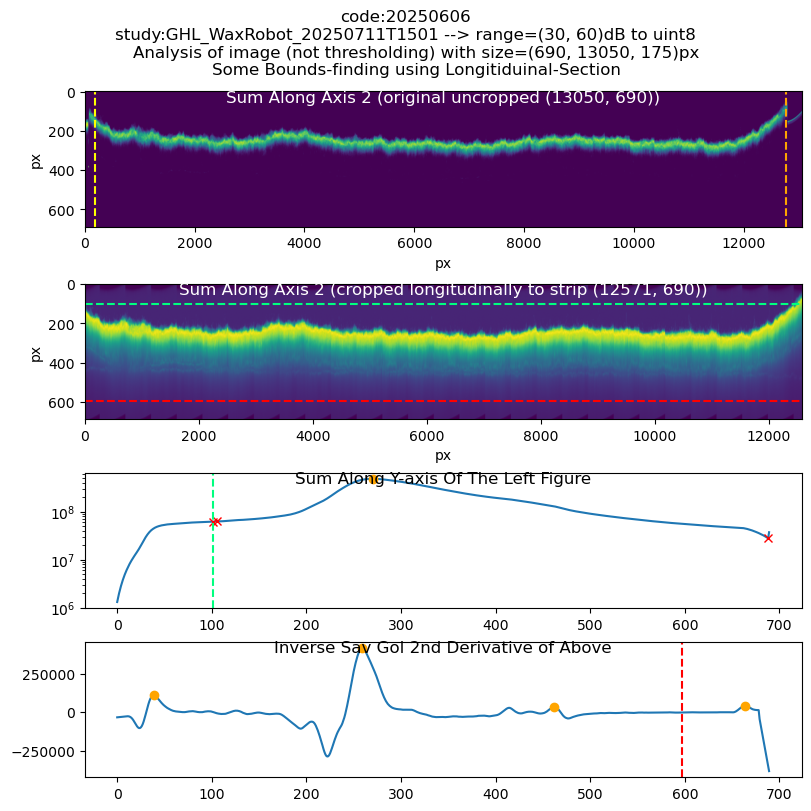

In [19]:
# Do automatic analysis using Longitiduinal-Section

def mk_analyse_bounds_6():
    #ndasum0 = sitk.GetArrayViewFromImage(simgmerged).sum(axis=0)[data_extracted['auto_bounds']['topdown_edge_left_px2']:data_extracted['auto_bounds']['topdown_edge_right_px2'],:]
    #ndasum0 = sitk.GetArrayViewFromImage(simgmerged).sum(axis=0)
    #ndasum1 = nda.sum(axis=1)
    #ndasum2 = nda.sum(axis=2)

    fig = plt.figure(figsize=(8,8),constrained_layout=True);
    fig.suptitle(
    """code:{:s}\nstudy:{:s} --> range={:s}dB to uint8
    Analysis of image (not thresholding) with size={:s}px
    Some Bounds-finding using Longitiduinal-Section""" \
        .format(
            codename,
            octstudy.name,
            str((oct_scalar_min,oct_scalar_max)),
            str(seg.GetSize())
        )
    )
    gs = fig.add_gridspec(4,1);

    # fig_ax1 = fig.add_subplot(gs[0,0:2]);
    # fig_ax1.set_title('Sum Along Axis 0',y=0.95,verticalalignment='top')
    # fig_ax1.imshow(ndasum2,aspect='auto');
    # fig_ax1.set_xlabel('px');
    # fig_ax1.set_ylabel('px');

    ax = fig.add_subplot(gs[0,0]);
    ax.set_title('Sum Along Axis 2 (original uncropped {:})'.format(str(ndasum0.shape)),y=0.95,verticalalignment='top',color='white');
    ax.imshow(ndasum0.T,aspect='auto');
    ax.set_xlabel('px');
    ax.set_ylabel('px');
    ax.axvline(data_extracted['auto_bounds']['topdown_edge_left_px3'],color='yellow',linestyle='dashed');
    ax.axvline(data_extracted['auto_bounds']['topdown_edge_right_px3'],color='orange',linestyle='dashed');


    tmpimg = simgmerged[:,   data_extracted['auto_bounds']['topdown_edge_left_px3']:data_extracted['auto_bounds']['topdown_edge_right_px3'] , : ]
    nda = sitk.GetArrayViewFromImage(tmpimg)
    ndasum = np.sum(nda,axis=0);

    fig_ax1 = fig.add_subplot(gs[1,0]);
    fig_ax1.set_title('Sum Along Axis 2 (cropped longitudinally to strip {:})'.format(str(ndasum.shape)),y=0.95,verticalalignment='top',color='white');
    fig_ax1.imshow(ndasum.T,aspect='auto');
    fig_ax1.set_xlabel('px');
    fig_ax1.set_ylabel('px');

    nda_sum_curve = ndasum.sum(axis=0)
    pks = scipy.signal.find_peaks(nda_sum_curve,prominence=10000,height=10000)
    widths = scipy.signal.peak_widths(nda_sum_curve,pks[0])
    localmin = scipy.signal.argrelextrema(nda_sum_curve, np.less)[0]
    print(pks)
    print(widths)
    print(localmin)
    tallest_peak = np.argmax(pks[1]['peak_heights'])
    tallest_peak = np.argmax(pks[1]['peak_heights'])


    # look for top edge
    #data_extracted['auto_bounds']['thickness_depth_top_px'] = localmin[localmin<pks[0][tallest_peak]][-1].item();
    #data_extracted['auto_bounds']['thickness_depth_top_px'] = localmin[localmin<pks[0][tallest_peak]][-1].item();
    data_extracted['auto_bounds']['thickness_depth_top_px'] = localmin[0].item();


    fig_ax2 = fig.add_subplot(gs[2,0]);
    fig_ax2.set_title('Sum Along Y-axis Of The Left Figure',y=0.95,verticalalignment='top');
    fig_ax2.plot(nda_sum_curve);
    fig_ax2.plot(pks[0],nda_sum_curve[pks[0]],marker='o',linestyle='',color='orange');
    fig_ax2.plot(localmin,nda_sum_curve[localmin],marker='x',linestyle='',color='red');
    fig_ax2.set_yscale('log')



    # mark top edge
    fig_ax1.axhline( data_extracted['auto_bounds']['thickness_depth_top_px'] ,linestyle='dashed',color='springgreen')
    fig_ax2.axvline( data_extracted['auto_bounds']['thickness_depth_top_px'] ,linestyle='dashed',color='springgreen')




    savgol_of_sum_surve = scipy.signal.savgol_filter(nda_sum_curve,21,polyorder=3,deriv=2);
    pks2 = scipy.signal.find_peaks(-savgol_of_sum_surve,prominence=50000)
    print('pks2',pks2);
    fig_ax3 = fig.add_subplot(gs[3,0]);
    fig_ax3.set_title('Inverse Sav Gol 2nd Derivative of Above',y=0.95,verticalalignment='top');
    fig_ax3.plot(-savgol_of_sum_surve);
    fig_ax3.plot(pks2[0],-savgol_of_sum_surve[pks2[0]],marker='o',linestyle='',color='orange');

    # look for bottom edge
    #data_extracted['auto_bounds']['thickness_depth_bot_px'] = pks2[0][pks2[0] > max(pks[0])][1]
    if pks2[0][pks2[0] > max(pks[0])].shape[0]>=2:
        print('more than 2')
        #data_extracted['auto_bounds']['thickness_depth_bot_px'] = pks2[0][pks2[0] > max(pks[0])][1]
        data_extracted['auto_bounds']['thickness_depth_bot_px'] = (pks2[0][-1] - (pks2[0][-1]-pks2[0][-2])//3).item()
    elif pks2[0][pks2[0] > max(pks[0])].shape[0]==1:
        print('had 1')
        if(pks[0][pks[0] > (pks2[0][-2])].shape[0]>0):
            print('1st part')
            data_extracted['auto_bounds']['thickness_depth_bot_px'] = ((pks[0][pks[0] > (pks2[0][-2])][0]) + (pks2[0][-2]))//2;
        else:
            print('2nd part')
            data_extracted['auto_bounds']['thickness_depth_bot_px'] = (pks2[0][-1]+pks2[0][-2])//2;
    else:
        print('other, just go to right near the bottom')
        data_extracted['auto_bounds']['thickness_depth_bot_px'] = int(ndasum.shape[1]*0.95);
    fig_ax1.axhline( data_extracted['auto_bounds']['thickness_depth_bot_px'] ,linestyle='dashed',color='red')
    fig_ax3.axvline( data_extracted['auto_bounds']['thickness_depth_bot_px'] ,linestyle='dashed',color='red')

    return fig;
fig = mk_analyse_bounds_6();
# Save to processed folder
fig.savefig(octstudy.folder_study_processed/'processing_step1f.jpg'.format(time.strftime('%Y%m%d')))

In [20]:
pp.pprint(data_extracted)

{   'auto_bounds': {   'thickness_depth_bot_px': 597,
                       'thickness_depth_top_px': 101,
                       'topdown_edge_left_px': 66,
                       'topdown_edge_left_px2': 71,
                       'topdown_edge_left_px3': np.int64(194),
                       'topdown_edge_right_px': 12770,
                       'topdown_edge_right_px2': 12765,
                       'topdown_edge_right_px3': 12765},
    'auto_topdown_houghline': (   array([7093, 7022], dtype=uint64),
                                  array([1.56948405, 1.56948405]),
                                  array([122.,  77.]))}


In [21]:
del nda
del ndasum0
del ndasum1
del ndasum2

# Processing Step 2 - Now Could We Save A Smaller Cropped File? Yes

In [22]:
print( 'Original',simgmerged.GetSize() )
slicer_0 = slice( data_extracted['auto_bounds']['thickness_depth_top_px']  ,  data_extracted['auto_bounds']['thickness_depth_bot_px']  )
#slicer_1 = slice( data_extracted['auto_bounds']['topdown_edge_left_px2']  ,  data_extracted['auto_bounds']['topdown_edge_right_px2']  )
#slicer_1 = slice( data_extracted['auto_bounds']['topdown_edge_left_px']  ,  data_extracted['auto_bounds']['topdown_edge_right_px']  )
slicer_1 = slice( data_extracted['auto_bounds']['topdown_edge_left_px3']  ,  data_extracted['auto_bounds']['topdown_edge_right_px3']  )
print(' slicer_dim_0',slicer_0)
print(' slicer_dim_1',slicer_1)
simgmerged_longcropped = simgmerged[ : , slicer_1, :]
print( 'Long-cropped Simple ITK Image',simgmerged_longcropped.GetSize() )
if False:
    cropped_simple_itk_image = simgmerged[ slicer_0, slicer_1, :]
    print( 'Cropped Simple ITK Image',cropped_simple_itk_image.GetSize() )
    
    # save this byte-adjusted volume
    fname = octstudy.folder_study_processed/'{:s}_STACKED_CROPPED_RESCALED_{:}to{:}_uint8.vtk'.format(octstudy.name,oct_scalar_min,oct_scalar_max);
    #vdvol.dataset.save()
    if(fname.exists()):
        print('Stacked volume byte-size .vtk file already exists, will not recreate.');
    else:
        #mergedvol.save(fname);
        sitkwriter = sitk.ImageFileWriter();
        sitkwriter.SetFileName(fname.as_posix())
        sitkwriter.Execute(cropped_simple_itk_image)

Original (690, 13050, 175)
 slicer_dim_0 slice(101, 597, None)
 slicer_dim_1 slice(np.int64(194), 12765, None)
Long-cropped Simple ITK Image (690, 12571, 175)


# Processing Step 3 - Along Strip Analysis A

In [24]:
# Use the automatically determined boundaries along the strip to restrict the depth
# The automatically determined boundaries are too lenient, and initial cross-sections looks funny
#seg_sliced = seg[:,data_extracted['auto_bounds']['topdown_edge_left_px2']:data_extracted['auto_bounds']['topdown_edge_right_px2'],:]
seg_sliced = seg[:,slicer_1,:];

seg_sliced.GetSize()

(690, 12571, 175)

In [25]:
# Prepare a temporary location to store images as we go through each slice
#folder_figure_temp = Path(f'C:\\TEMP\\OCTtmp\\{octstudy.name}');
folder_figure_temp.mkdir(parents=True,exist_ok=True);

timing 0.0006
timing 4.7366
(175, 10, 690)
timing 6.3778
timing 7.5095
(array([213]), {'peak_heights': array([136.8]), 'prominences': array([136.8]), 'left_bases': array([171]), 'right_bases': array([295]), 'widths': array([52.52115385]), 'width_heights': array([68.4]), 'left_ips': array([201.65384615]), 'right_ips': array([254.175])})
pks1 (array([192, 200, 211, 229, 233, 243, 252, 254, 269, 271]), {'peak_heights': array([0.45675057, 0.29855271, 0.72915688, 0.16612381, 0.11245208,
       0.13595055, 0.21469583, 0.19894796, 0.25343992, 0.26019198]), 'prominences': array([0.44328509, 0.03862522, 0.72915688, 0.14823026, 0.00176528,
       0.10861838, 0.20295105, 0.00232399, 0.00080834, 0.24998068]), 'left_bases': array([156, 198, 156, 223, 232, 239, 239, 253, 239, 239]), 'right_bases': array([204, 204, 326, 239, 239, 245, 260, 260, 270, 326])})
widths1 (array([ 0.78919182,  3.00329463, 10.85999211,  0.64969372,  0.56085011,
       13.96561628]), array([0.11156944, 0.08164136, 0.1132203 ,

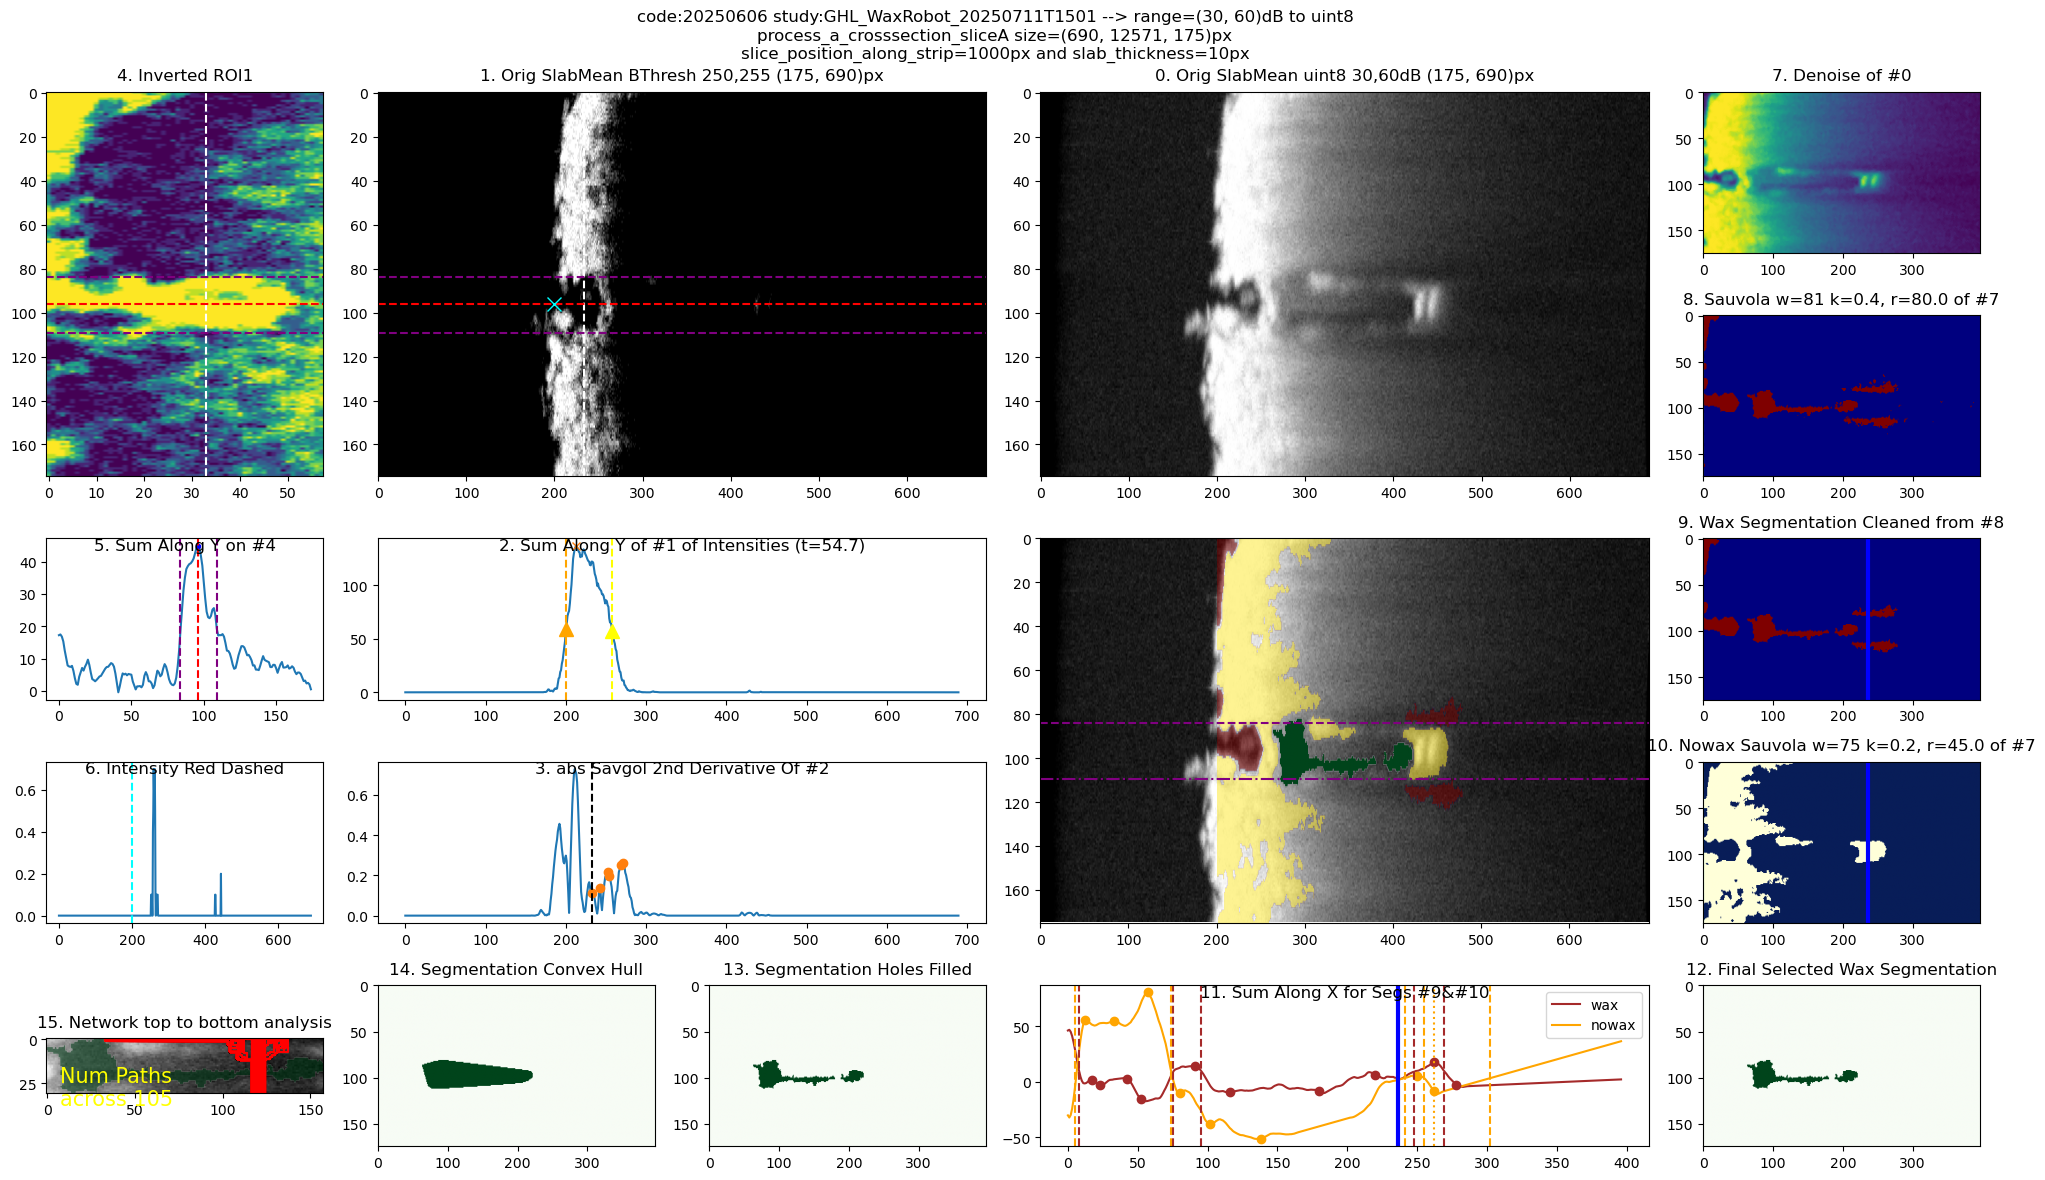

In [ ]:
def process_a_crosssection_slice_rework_method(seg : sitk.Image, slab_thickness_px,slice_position_along_strip_px, mkplot=True):
    slab_thickness = slab_thickness_px;
    sliceinfo = {};
    timestart = time.monotonic_ns();


    print('timing',(time.monotonic_ns()-timestart)*1e-6)
    if(slab_thickness>1):
        seg_subset = seg[:,slice_position_along_strip_px-slab_thickness//2:slice_position_along_strip_px+slab_thickness//2,:]
        img_subset = simgmerged_longcropped[:,slice_position_along_strip_px-slab_thickness//2:slice_position_along_strip_px+slab_thickness//2,:]
    else:
        seg_subset = seg[:,slice_position_along_strip_px:slice_position_along_strip_px+1,:]
        img_subset = simgmerged_longcropped[:,slice_position_along_strip_px:slice_position_along_strip_px+1,:]
    print('timing',(time.monotonic_ns()-timestart)*1e-6)
    nda = sitk.GetArrayFromImage(seg_subset);
    print(nda.shape)
    nda_mean = np.mean(nda,axis=1);
    nda_mean_sum = np.sum(nda_mean,axis=0);
    print('timing',(time.monotonic_ns()-timestart)*1e-6)

    orignda = sitk.GetArrayViewFromImage(img_subset);
    orignda_mean = np.mean(orignda,axis=1);
    print('timing',(time.monotonic_ns()-timestart)*1e-6)



    if mkplot:
        #fig,ax = plt.subplots(3,2,figsize=(20,12));
        fig = plt.figure(figsize=(20,12));
        gs = fig.add_gridspec(5,6); # rows,cols
        fig.suptitle('code:{:s} study:{:s} --> range={:s}dB to uint8\nprocess_a_crosssection_sliceA size={:s}px\nslice_position_along_strip={:.0f}px and slab_thickness={:.0f}px'.format(
            codename,
            octstudy.name,
            str((oct_scalar_min,oct_scalar_max)),
            str(seg.GetSize()),
            slice_position_along_strip_px,
            slab_thickness_px)
        )


    # SHOW FULL IMAGES
    if mkplot:
        ax = fig.add_subplot(gs[0:2,1:3]);
        ax.set_title('1. Orig SlabMean BThresh {:},{:} {:s}px'.format(step1_binarythresholding_lo,step1_binarythresholding_hi,str(orignda_mean.shape)),y=1.0,verticalalignment='bottom')
        ax.imshow(nda_mean,aspect='auto',cmap='grey');
        ax_gray_img_binarythresh = ax;
    
        ax = fig.add_subplot(gs[0:2,3:5]);
        ax.set_title('0. Orig SlabMean uint8 {:},{:}dB {:s}px'.format(oct_scalar_min,oct_scalar_max,str(orignda_mean.shape)),y=1.0,verticalalignment='bottom')
        ax.imshow(orignda_mean,aspect='auto',cmap='grey');
        ax_gray_img_orig = ax;


    # SHOW STEP 2- SUM OF BINARY THRESHOLDED WHOLE-IMAGE
    #pixel_depth_strip_top_sum_threshold = 100;
    pixel_depth_strip_top_sum_threshold = nda_mean_sum.max()*0.4;
    pixel_depth_strip_top = np.nonzero(nda_mean_sum>pixel_depth_strip_top_sum_threshold)[0][0];
    pixel_depth_strip_bot = np.nonzero(nda_mean_sum>pixel_depth_strip_top_sum_threshold)[0][-1];

    if mkplot:
        ax = fig.add_subplot(gs[2,1:3])
        ax.set_title('2. Sum Along Y of #1 of Intensities (t={:.1f})'.format(pixel_depth_strip_top_sum_threshold),y=0.95,verticalalignment='top')
        ax.plot(nda_mean_sum);
    
        # Catch a situation where there's a strong undesirable feature deeper down in the strip that dominnates the response
        pks = scipy.signal.find_peaks(abs(nda_mean_sum),height=24,prominence=10,distance=10,width=0);
        print(pks)
        if( (len(pks[0])==2) and ( pks[1]['widths'][1]<pks[1]['widths'][0] ) and (pixel_depth_strip_top>pks[0][0]) ):
            pixel_depth_strip_top = pks[1]['left_bases'][0];
            pixel_depth_strip_bot = pks[1]['right_bases'][0];
        ax.plot(pks[0],nda_mean_sum[pks[0]],'x',linestyle='none')

    
    if mkplot:
        #ax[1,1].set_title('Depth-Mean And X-Sum Vs Y',y=0.95,verticalalignment='top')
        ax.plot(pixel_depth_strip_top, nda_mean_sum[pixel_depth_strip_top] , marker='^', markersize=10,color='orange');
        ax.axvline(pixel_depth_strip_top,linestyle='--',color='orange');
        ax.plot(pixel_depth_strip_bot, nda_mean_sum[pixel_depth_strip_bot] , marker='^', markersize=10,color='yellow');
        ax.axvline(pixel_depth_strip_bot,linestyle='--',color='yellow');


    # SHOW STEP 3 - Savgol of #2
    nda_mean_sum_curvature = scipy.signal.savgol_filter(nda_mean_sum,21,polyorder=3,deriv=2);
    pks = scipy.signal.find_peaks(abs(nda_mean_sum_curvature),height=0.1,prominence=0)
    # restrict peaks to be right of the white line
    pksculled=pks[0][ pks[0]> round( (pixel_depth_strip_bot-pixel_depth_strip_top)/2 + pixel_depth_strip_top ) ] # halfway between orange and yellow
    widths = scipy.signal.peak_widths(abs(nda_mean_sum_curvature),pksculled,rel_height=0.5)
    print('pks1',pks)
    print('widths1',widths)
    if mkplot:
        #ax[2,1].plot(np.diff(nda_mean_sum,1));
        ax = fig.add_subplot(gs[3,1:3]);
        ax.set_title('3. abs Savgol 2nd Derivative Of #2',y=0.95,verticalalignment='top')
        ax.plot(abs(nda_mean_sum_curvature));
        ax.plot(pksculled,abs(nda_mean_sum_curvature[pksculled]),'o',linestyle='');
    
    #pixel_depth_wax_center = round( (pixel_depth_strip_bot-pixel_depth_strip_top)/2 + pixel_depth_strip_top )
    
    if(len(pksculled)==0):
        pixel_depth_wax_center = round( (pixel_depth_strip_bot-pixel_depth_strip_top)*0.8 + pixel_depth_strip_top );
    else:
        pixel_depth_wax_center = pksculled[0].item();
    
    if mkplot:
        ax.axvline(pixel_depth_wax_center,linestyle='--',color='black');
        ax_gray_img_binarythresh.axvline(pixel_depth_wax_center,linestyle='--',color='white');


    # SHOW STEP 4 - Inverted ROI1
    if mkplot:
        ax = fig.add_subplot(gs[0:2,0])
        ax.set_title('4. Inverted ROI1',y=1.0,verticalalignment='bottom')
    imgtmp = nda_mean[:,pixel_depth_strip_top:pixel_depth_strip_bot];
    if mkplot:
        ax.imshow(np.max(imgtmp)-imgtmp,aspect='auto');
        # show the white line
        ax.axvline(pixel_depth_wax_center-pixel_depth_strip_top,linestyle='--',color='white');
        ax_thresholded_roi1 = ax;
    
    # SHOW STEP 5 - INVERSE SUM OF DEPTH ALONG WHITE LINE OF #4
    sum_of_depth_intensities = np.sum(imgtmp,axis=1);
    sum_of_depth_intensities = max(sum_of_depth_intensities) - sum_of_depth_intensities;
    sum_of_depth_intensities = scipy.signal.savgol_filter(sum_of_depth_intensities,5,3,0);
    if mkplot:
        ax = fig.add_subplot(gs[2,0]);
        ax.set_title('5. Sum Along Y on #4',y=0.95,verticalalignment='top');
        ax.plot(sum_of_depth_intensities)
        #ax.plot( scipy.signal.savgol_filter(sum_of_depth_intensities,21,polyorder=3,deriv=2)*100 );
    #pks = scipy.signal.find_peaks(sum_of_depth_intensities,width=20,prominence=1.2)
    pks = scipy.signal.find_peaks(sum_of_depth_intensities,height=25,prominence=20,width=5)
    widths = scipy.signal.peak_widths(sum_of_depth_intensities,pks[0],rel_height=0.6)
    print(pks);
    print(widths);
    if mkplot:
        ax.plot(pks[0],sum_of_depth_intensities[pks[0]],linestyle='none',marker='.',color='blue')
    #assert(pks[0].shape[0]>=1)

    if(pks[0].shape[0]>0):
        # retain widths of the single largest peak
        #pkidxlargest = np.argmax(widths[0]);
        pkidxlargest = np.argmax(pks[1]['prominences']);
        pkcenter = int(round( widths[3][pkidxlargest]- widths[2][pkidxlargest] )//2 + widths[2][pkidxlargest]);
        px_wax_transverse_edges = ( widths[2][pkidxlargest].item() , widths[3][pkidxlargest].item() )
        #px_wax_transverse_edges = ( pks[0][pkidxlargest]-pks[1]['widths'][pkidxlargest]/2 , pks[0][pkidxlargest]+pks[1]['widths'][pkidxlargest]/2 )
    else:
        # assert that it's greater than zero.
        # if it's exactly zero, we need to refine what we are looking for a bit more because
        # the wax valve must be weak in the image.
        # 
        # assume the wax peak will be within the central 50% of the image
        if True:
            threshold = np.histogram(sum_of_depth_intensities,3)[1][2];
            print('Plot 5 - thresholding above',threshold)
            threshold_transition_points = np.where(np.diff(sum_of_depth_intensities>threshold))[0]
            px_wax_transverse_edges = (threshold_transition_points[0],threshold_transition_points[-1]);
            pkcenter = (px_wax_transverse_edges[1]-px_wax_transverse_edges[0])//2+px_wax_transverse_edges[0]
            if mkplot:
                ax.axhline(threshold,linestyle='--',color='black');
        if False:
            # old method that I stopped using 6/9/2925
            #test
            #ax.plot(pks[0],sum_of_depth_intensities[pks[0]],linestyle='none',marker='.',color='blue')

            restrict_range_slice = slice(sum_of_depth_intensities.shape[0]//4,sum_of_depth_intensities.shape[0]-sum_of_depth_intensities.shape[0]//4);
            pkcenter = sum_of_depth_intensities.shape[0]//2;
            px_wax_transverse_edges = ( (restrict_range_slice.start,restrict_range_slice.stop) )
            widths = scipy.signal.peak_widths(sum_of_depth_intensities,[pkcenter],wlen=15);
            px_wax_transverse_edges = (int(widths[1][0].item()),int(widths[2][0].item()))
            print('Odd Condition Widths:',widths)
            pksodd = scipy.signal.find_peaks(sum_of_depth_intensities,height=1,prominence=10,width=0)
            qualify_pksodd = pksodd[0]>sum_of_depth_intensities.shape[0]//4
            print('Odd Condition Pks:',pksodd)
            print('Odd Condition Peak Indexes:',qualify_pksodd)
            if(any(qualify_pksodd)):
                #px_wax_transverse_edges = (int(widths[1][0].item()),int(widths[2][0].item()))            
                if mkplot:
                    ax.plot(pksodd[0][qualify_pksodd],sum_of_depth_intensities[pksodd[0][qualify_pksodd]],linestyle='none',marker='.',color='magenta')
                px_wax_transverse_edges = ( pksodd[1]['left_bases'][qualify_pksodd][0], pksodd[1]['right_bases'][qualify_pksodd][0] )

    if mkplot:
        #ax.plot(qualify_pksodd,sum_of_depth_intensities[qualify_pksodd],linestyle='none',marker='.',color='magenta')
        ax_thresholded_roi1.axhline(pkcenter,linestyle='--',color='red');
        ax.axvline(pkcenter,linestyle='--',color='red');

    if mkplot:
        #ax_thresholded_roi1.axhline(pkcenter,linestyle='--',color='red');
        ax_gray_img_binarythresh.axhline(pkcenter,linestyle='--',color='red');
    if mkplot:
        #ax_thresholded_roi1.axhline((px_wax_transverse_edges[0],px_wax_transverse_edges[1]),linestyle='--',color='purple')
        ax.axvline(px_wax_transverse_edges[0],linestyle='--',color='purple');
        ax.axvline(px_wax_transverse_edges[1],linestyle='--',color='purple');
        ax_thresholded_roi1.axhline(px_wax_transverse_edges[0],linestyle='--',color='purple');
        ax_thresholded_roi1.axhline(px_wax_transverse_edges[1],linestyle='--',color='purple');
        ax_gray_img_binarythresh.axhline(px_wax_transverse_edges[0],linestyle='--',color='purple');
        ax_gray_img_binarythresh.axhline(px_wax_transverse_edges[1],linestyle='--',color='purple');


    # SHOW STEP 6 - SEED POINT SEARCH, TOP RIGHT IN WAX AREA
    # take cross-section along white dashed line
    # take intensity over dash red line out of plane of strip
    if mkplot:
        ax = fig.add_subplot(gs[3,0]);
        ax.set_title('6. Intensity Red Dashed',y=0.95,verticalalignment='top');
    red_outofplane_intensity = nda_mean[pkcenter,:];
    intensity_purple_bounds = nda_mean.sum(axis=0);
    if mkplot:
        ax.plot(red_outofplane_intensity)
        #ax[2,0].plot( intensity_purple_bounds, color='purple' )

    # specify a seed point
    #pks = scipy.signal.find_peaks(red_outofplane_intensity,distance=30)
    #wax_top_seed_candidate_px = (pks[0][0].item(),pkcenter)
    pks = scipy.signal.find_peaks(red_outofplane_intensity[0:pixel_depth_strip_bot],height=0.50,prominence=0,distance=10)
    if(pks[0].shape[0]>0):
        # normal behavior

        # discard peaks left of the white dashed line
        pks2culled=pks[0][ pks[0]< pixel_depth_wax_center ] # PEAKS LESS THAN THE WHITE DASHED LINE
        widths = scipy.signal.peak_widths(red_outofplane_intensity[0:pixel_depth_strip_bot],pks2culled,rel_height=0.5)
        print('pks2',pks)
        print('wid2',widths)
        if(widths[0].shape[0]==0):
            pkidxlargest = 0;
        else:
            pkidxlargest = np.argmax(widths[0]);
        wax_top_seed_candidate_px = (round((pks[1]['right_bases'][pkidxlargest]-pks[1]['left_bases'][pkidxlargest])/2 + pks[1]['left_bases'][pkidxlargest]) ,pkcenter)
    else:
        # the top of the strip around where the wax is at was really difficult to discern
        print('not a strong strip top at the wax surface')
        # assume the top is the pixel_depth_strip_top
        wax_top_seed_candidate_px = (pixel_depth_strip_top,pkcenter);

    if mkplot:
        ax.plot(pks[0],red_outofplane_intensity[pks[0]],linestyle='none',marker='.',color='blue')
        ax_gray_img_binarythresh.plot(*wax_top_seed_candidate_px, 'x', markersize=10 , color='cyan' );
        ax.axvline(wax_top_seed_candidate_px[0],linestyle='--',color='cyan');




    # aggregate Part A1 data
    sliceinfo['pixel_depth_strip_top_sum_threshold'] = pixel_depth_strip_top_sum_threshold;
    sliceinfo['pixel_depth_strip_top'] = pixel_depth_strip_top.item();
    sliceinfo['pixel_depth_strip_bot'] = pixel_depth_strip_bot.item();
    sliceinfo['pixel_depth_wax_center'] = pixel_depth_wax_center;
    sliceinfo['px_wax_transverse_edges'] = px_wax_transverse_edges;
    sliceinfo['wax_top_seed_candidate_px'] = wax_top_seed_candidate_px;
    print('timing start part 3b',(time.monotonic_ns()-timestart)*1e-6)





    # DENOISE #0
    if mkplot:
        ax = fig.add_subplot(gs[0,5])
        ax.set_title('7. Denoise of #0',y=1.0,verticalalignment='bottom')
    print('-- 7 DENOISE --')
    print('timing',(time.monotonic_ns()-timestart)*1e-6)
    #roi2slicedepth = slice(sliceinfo['pixel_depth_strip_top'],None);
    roi2slicedepth = slice(sliceinfo['pixel_depth_strip_top'],data_extracted['auto_bounds']['thickness_depth_bot_px']);
    orignda_mean_strip = orignda_mean[:,roi2slicedepth];
    # denoise image
    #denoisedorig = skimage.filters.rank.median(skimage.util.img_as_ubyte(orignda_mean), skimage.morphology.disk(2))
    denoisedorigstrip = skimage.filters.rank.median(skimage.util.img_as_ubyte(orignda_mean_strip/orignda_mean_strip.max()), skimage.morphology.disk(2));
    #denoisedorigstrip = orignda_mean_strip;
    #denoisedorigstrip = skimage.filters.rank.median(skimage.util.img_as_ubyte(orignda_mean/orignda_mean.max()), skimage.morphology.disk(2));
    if mkplot:
        ax.imshow(denoisedorigstrip,aspect='auto')
        #ax.axvline(sliceinfo['pixel_depth_strip_bot']-slicey.start,color='yellow',linestyle='dashed')
        #ax.plot(sliceinfo['wax_top_seed_candidate_px'][0]-slicey.start,sliceinfo['wax_top_seed_candidate_px'][1]-slicex.start,marker='x',markersize=10)
        #ax1b = ax;
        ax_roi2_denoised_b = ax;
    
    if False:
        # MULTIOTSU
        # Applying multi-Otsu threshold for the default value, generating
        # several classes.
        print('-- 8 MULTIOTSU --')
        print('timing',(time.monotonic_ns()-timestart)*1e-6)
        thresholds = skimage.filters.threshold_multiotsu(denoisedorigstrip,classes=5)
        # Using the threshold values, we generate the three regions.
        regions = np.digitize(denoisedorigstrip, bins=thresholds)
        #print('5. Multiotsu Thresholds',thresholds);
        if mkplot:
            ax = fig.add_subplot(gs[1,5])
            ax.set_title('8. Multi-Otsu of #7\n{:s}'.format(str(thresholds)),y=1.0,verticalalignment='bottom')
            ax.imshow(regions,cmap='jet',aspect='auto')
        sliceinfo['testseg_otsu_regions'] = regions;
        sliceinfo['testseg_otsu_thresholds'] = thresholds;

        #The non-zero regions should be disregarded


    print('-- ADATIVE THRESHOLDING --')
    print('timing',(time.monotonic_ns()-timestart)*1e-6)
    # ADAPTIVE THRESHOLDING (SAUVOLA)
    # Adaptive Thresholding
    window_size = 81
    # thresh_niblack = skimage.filters.threshold_niblack(denoisedorigstrip, window_size=window_size, k=0.1)
    #thresh_sauvola = skimage.filters.threshold_sauvola(orignda_mean_wax_denoised, window_size=window_size, k=0.1,r=thresholds[0]/2.0)
    #thresh_sauvola = skimage.filters.threshold_sauvola(orignda_mean_wax_denoised, window_size=window_size, k=0.1,r=thresholds[0]/2.0)
    sauvola_k = 0.4;
    #sauvola_r = thresholds[1];
    sauvola_r = 80.0;
    print('Do Sauvola with Window={:} K={:.03f} R={:.03f}'.format(window_size,sauvola_k,sauvola_r));
    thresh_sauvola = skimage.filters.threshold_sauvola(denoisedorigstrip, window_size=window_size, k=sauvola_k, r=sauvola_r)

    # # ax = fig.add_subplot(gs[2,1])
    # # ax.set_title('Thresh Niblack w={:} k=0.1'.format(window_size,),y=1.0,verticalalignment='bottom')
    # # ax.imshow(orignda_mean_wax_denoised<thresh_niblack,cmap='jet',aspect='auto')

    seg_thresh_sauvola = denoisedorigstrip<thresh_sauvola

    if mkplot:
        ax = fig.add_subplot(gs[1,5])
        ax.set_title('8. Sauvola w={:} k={:}, r={:.1f} of #7'.format(window_size,sauvola_k,sauvola_r),y=1.0,verticalalignment='bottom')
        ax.imshow(seg_thresh_sauvola,cmap='jet',aspect='auto')
        ax.axvline(sliceinfo['wax_top_seed_candidate_px'][0] - sliceinfo['pixel_depth_strip_top'],color='cyan',linestyle='dashed')
    print('timing',(time.monotonic_ns()-timestart)*1e-6)

    #roi2slicetransverse = slice(int(sliceinfo['px_wax_transverse_edges'][0]*0.8) , int(sliceinfo['px_wax_transverse_edges'][1]*1.2))
    #seg_thresh_sauvola = seg_thresh_sauvola[roi2slicetransverse , : ];
    seg_thresh_sauvola = skimage.morphology.remove_small_objects(seg_thresh_sauvola, 50);
    
    if mkplot:
        ax = fig.add_subplot(gs[2,5])
        ax.set_title('9. Wax Segmentation Cleaned from #8',y=1.0,verticalalignment='bottom')
        ax.imshow(seg_thresh_sauvola,cmap='jet',aspect='auto')
        #ax.axvline(sliceinfo['wax_top_seed_candidate_px'][0] - sliceinfo['pixel_depth_strip_top'],color='cyan',linestyle='dashed')
        ax_seg_wax = ax;
    print('timing',(time.monotonic_ns()-timestart)*1e-6)



    # # Show Sauvola overlayed
    # ax = fig.add_subplot(gs[2:4,3:5]);
    # ax.imshow(orignda_mean,cmap='gray',aspect='auto',origin='upper');
    # extent = (roi2slicedepth.start,roi2slicedepth.stop,roi2slicetransverse.stop,roi2slicetransverse.start)
    # ax.imshow(seg_thresh_sauvola,alpha=(seg_thresh_sauvola).astype(float)*0.8,cmap='jet',aspect='auto',extent=extent,origin='upper')
    # ax.set_xlim(0, orignda_mean.shape[1])
    # ax.set_ylim(orignda_mean.shape[0],0)


    if False:
        # SEGMENTATIOIN PARSE
        print('-- SEGMENTATION PRUNING --')
        print('timing',(time.monotonic_ns()-timestart)*1e-6)
        regionparamlist = [];

        seglabel = skimage.measure.label(seg_thresh_sauvola);
        total_area_filled = 0;
        total_area = 0;
        total_area_convex = 0;
        seg_selected_labels = np.zeros_like(seg_thresh_sauvola);
        accepted_labels = [];
        for region in skimage.measure.regionprops(seglabel):
            region : skimage.measure._regionprops.RegionProperties;

            # skip labels where bbox(x) is zero (touches left side)
            if(region.bbox[1]==0):
                continue;
            
            # skip labels where area_convex is less than window_size for sauvola thresholding
            if(region.area_convex <= window_size):
                continue;

            print('Region id:{:} bbox:{:} area:{:} area_filled:{:} area_convex:{:}'.format(
                region.label,
                str(region.bbox),
                region.area,
                region.area_filled,
                region.area_convex,
            ))
            total_area += region.area.item();
            total_area_filled += region.area_filled.item();
            total_area_convex += region.area_convex.item();
        
            #seg_selected_labels += region.image;
            accepted_labels.append(region.label);

            #print(region.centroid, sliceinfo['wax_top_seed_candidate_px'][0], sliceinfo['pixel_depth_strip_top'])

            regionparamlist.append({
                'area':total_area,
                'area_filled':total_area_filled,
                'area_convex':total_area_convex,
            })

        # use only the qualified labels as the segmentation mask
        seg_selected_labels[np.where(np.isin(seglabel,accepted_labels))] = 1;


    # # Show Sauvola overlayed
    # ax = fig.add_subplot(gs[2:4,3:5]);
    # ax.imshow(orignda_mean,cmap='gray',aspect='auto',origin='upper');
    # extent = (roi2slicedepth.start,roi2slicedepth.stop,roi2slicetransverse.stop,roi2slicetransverse.start)
    # ax.imshow(seg_selected_labels,alpha=(seg_selected_labels).astype(float)*0.8,cmap='jet',aspect='auto',extent=extent,origin='upper')
    # ax.set_xlim(0, orignda_mean.shape[1])
    # ax.set_ylim(orignda_mean.shape[0],0)




    print('-- ADATIVE THRESHOLDING 2 --')
    print('timing',(time.monotonic_ns()-timestart)*1e-6)
    # ADAPTIVE THRESHOLDING (SAUVOLA)
    # Adaptive Thresholding
    window_size = 75
    # thresh_niblack = skimage.filters.threshold_niblack(denoisedorigstrip, window_size=window_size, k=0.1)
    #thresh_sauvola = skimage.filters.threshold_sauvola(orignda_mean_wax_denoised, window_size=window_size, k=0.1,r=thresholds[0]/2.0)
    #thresh_sauvola = skimage.filters.threshold_sauvola(orignda_mean_wax_denoised, window_size=window_size, k=0.1,r=thresholds[0]/2.0)
    sauvola_k = 0.2;
    #sauvola_r = thresholds[1];
    sauvola_r = 45.0;
    print('Do Sauvola with Window={:} K={:.03f} R={:.03f}'.format(window_size,sauvola_k,sauvola_r));
    # invert so we are now looking for NOWAX areas
    thresh_sauvola = skimage.filters.threshold_sauvola(1-denoisedorigstrip, window_size=window_size, k=sauvola_k, r=sauvola_r)

    # # ax = fig.add_subplot(gs[2,1])
    # # ax.set_title('Thresh Niblack w={:} k=0.1'.format(window_size,),y=1.0,verticalalignment='bottom')
    # # ax.imshow(orignda_mean_wax_denoised<thresh_niblack,cmap='jet',aspect='auto')

    seg_thresh_sauvola2 = (1-denoisedorigstrip)<thresh_sauvola
    seg_thresh_sauvola2 = skimage.morphology.remove_small_objects(seg_thresh_sauvola2, 50);

    if mkplot:
        ax = fig.add_subplot(gs[3,5])
        ax.set_title('10. Nowax Sauvola w={:} k={:}, r={:.1f} of #7'.format(window_size,sauvola_k,sauvola_r),y=1.0,verticalalignment='bottom')
        ax.imshow(seg_thresh_sauvola2,cmap='YlGnBu_r',aspect='auto')
        ax.axvline(sliceinfo['wax_top_seed_candidate_px'][0] - sliceinfo['pixel_depth_strip_top'],color='cyan',linestyle='dashed')
        ax_seg_nowax = ax;
    print('timing',(time.monotonic_ns()-timestart)*1e-6)


    # Show Sauvola overlayed
    if False:
        ax = fig.add_subplot(gs[2:4,3:5]);
        ax.imshow(orignda_mean,cmap='gray',aspect='auto',origin='upper');
        #extent = (roi2slicedepth.start,roi2slicedepth.stop,roi2slicetransverse.stop,roi2slicetransverse.start)
        extent = (roi2slicedepth.start,roi2slicedepth.stop,orignda_mean.shape[0],0)
        ax.imshow(seg_thresh_sauvola,alpha=(seg_thresh_sauvola).astype(float)*0.8,cmap='jet',aspect='auto',extent=extent,origin='upper')
        extent = (roi2slicedepth.start,roi2slicedepth.stop,orignda_mean.shape[0],0)
        ax.imshow(seg_thresh_sauvola2,alpha=(seg_thresh_sauvola2).astype(float)*0.8,cmap='viridis',aspect='auto',extent=extent,origin='upper')
        ax.set_xlim(0, orignda_mean.shape[1])
        ax.set_ylim(orignda_mean.shape[0],0)

    # Find Wax Bottom valve
    orignda_mean_sum = np.sum(orignda_mean[:,roi2slicedepth],axis=0);
    orignda_mean_sum = orignda_mean_sum/max(orignda_mean_sum)
    seg1_sum = np.sum(seg_thresh_sauvola,axis=0);
    #seg1_sum = seg1_sum/max(seg1_sum);
    seg1_sum = scipy.signal.detrend(seg1_sum);

    seg2_sum = np.sum(seg_thresh_sauvola2,axis=0);
    #seg2_sum = seg2_sum/max(seg2_sum);
    seg2_sum = scipy.signal.detrend(seg2_sum);

    # where do seg1_sum and seg2_sum curves intersect each other?
    seg1andseg2_intersection_points = np.where(np.diff(np.sign(seg1_sum-seg2_sum)))[0];
    print('Nowax and Wax segmentations cross at:',seg1andseg2_intersection_points)


    # nowax_goes_above2 = nowax_goes_above[np.where(np.diff(nowax_goes_above)>1)[0]]
    # print('Nowax goes above2 at:',nowax_goes_above2)

    # find runs or humps with zeros on either end
    #condition = condition = seg2_sum==0;
    #runboundaries = np.where(np.concatenate([[condition[0]],condition[:-1]!=condition[1:],[True]]))[0];
    #num_nowax_humps = (len(runboundaries)-1)//2;
    #print('num_nowax_humps HUMPS:', num_nowax_humps);
    #( seg1_sum > seg2_sum )
    
    # np.logical_or(
    #     np.logical_or((ndasum_curve < median)*(np.roll(ndasum_curve, -1) > median), 
    #                     (ndasum_curve > median)*(np.roll(ndasum_curve, -1) < median)),
    #     ndasum_curve == median)
    #np.where(np.sign(seg1_sum > seg2_sum))[0]
    if False:
        condition = seg1_sum > seg2_sum;
        inflection_wax_over_nonwax = np.where((condition==np.roll(condition,1))==False)[0];
        inflection_wax_over_nonwax = inflection_wax_over_nonwax[inflection_wax_over_nonwax>10]
        print('Inflection Points Wax over Nonwax:',inflection_wax_over_nonwax);

        inflection_wax_over_nonwax[~np.logical_or(*([inflection_wax_over_nonwax>x for x in pks[0][-2:]]))][-1]

        inflection_count_left_of_1st_peak_from_left = ~np.any([inflection_wax_over_nonwax>x for x in pks[0][-1:]],axis=0);
        print('inflection_count_left_of_1st_peak:',inflection_count_left_of_1st_peak_from_left);
        #inflection_count_left_of_2nd_peak = ~np.logical_or(*([inflection_wax_over_nonwax>x for x in pks[0][-2:]]));
        inflection_count_left_of_2nd_peak = ~np.any([inflection_wax_over_nonwax>x for x in pks[0][-2:]],axis=0);
        print('inflection_count_left_of_2nd_peak:',inflection_count_left_of_2nd_peak);
        num_nowax_humps = 0;
        if(len(nowax_goes_above)==3 ):
            num_nowax_humps = 1;
        elif(sum(inflection_count_left_of_2nd_peak) == 2):
            num_nowax_humps = 2;
        elif(sum(inflection_count_left_of_2nd_peak) > 2):
            num_nowax_humps = 3;
    
    # if(num_nowax_humps==0):
    #     waxbottom_depth_position = inflection_wax_over_nonwax[inflection_count_left_of_1st_peak_from_left][-1];

    # INITIAL SETTING OF DEPTH

    if False:
        #waxbottom_depth_position = inflection_wax_over_nonwax[inflection_count_left_of_2nd_peak][-1];    ''
        # find 2nd peak in nowax from right
        waxbottom_nowax_region_depth = pks[0][-1];
        # pick crossing to the left of the 2nd peak in nowax
        waxbottom_depth_position = seg1andseg2_intersection_points[seg1andseg2_intersection_points<waxbottom_nowax_region_depth][-1];
    
    if False:
        print('peak picking: using 2nd rightmost');
        waxbottom_depth_position = pks[0][-2];


    # if(num_nowax_humps==1):
    #     if(len(inflection_count_left_of_1st_peak_from_left)>0 and sum(inflection_count_left_of_1st_peak_from_left)>0):
    #         waxbottom_depth_position = inflection_wax_over_nonwax[inflection_count_left_of_1st_peak_from_left][-2];
    #     else:
    #         print('humps 1 odd')
    #         # odd condition, sparse irregular wax
    #         waxbottom_depth_position = nowax_goes_above[-1]
            
    # elif(num_nowax_humps==2):
    #     waxbottom_depth_position = inflection_wax_over_nonwax[inflection_count_left_of_2nd_peak][-1];
    
    # elif(num_nowax_humps==3):
    #     #waxbottom_depth_position = inflection_wax_over_nonwax[-3];
    #     waxbottom_depth_position = pks[0][-2];
    
    # else:
    #     #waxbottom_depth_position = inflection_wax_over_nonwax[inflection_count_left_of_2nd_peak][-1];    ''
    #     # find 2nd peak in nowax from right
    #     waxbottom_nowax_region_depth = pks[0][-1];
    #     # pick crossing to the left of the 2nd peak in nowax
    #     waxbottom_depth_position = seg1andseg2_intersection_points[seg1andseg2_intersection_points<waxbottom_nowax_region_depth][-1];
    
    # 6/12/2025 AM - works well but some issues
    if False:
        if True:
            # check if the first right-most peak detected is around 215 depth
            px = 215;
            delta = 50; # +/- this many pixels from 150
            if( (pks[0][-1]>(px-delta/2)) and (pks[0][-1]<(px+delta/2)) ):
                print('peak picking: using 1st rightmost');
                waxbottom_depth_position = pks[0][-1];
            else:
                print('peak picking: using 2nd rightmost');
                waxbottom_depth_position = pks[0][-2];

        num_nowax_humps = 0;

        # check for deep 2-humps
        if(len(nowax_goes_above)>=4):
            if( pks[0][-1]>nowax_goes_above[-2] and pks[0][-1]<nowax_goes_above[-1]):
                if( pks[0][-2]>nowax_goes_above[-4] and pks[0][-2]<nowax_goes_above[-3]):
                    num_nowax_humps = 2;
        
        # check for standard 1-hump
        if( len(nowax_goes_above)==3 and pks[0][-1]>nowax_goes_above[-2] and pks[0][-1]<nowax_goes_above[-1]):
            num_nowax_humps=1;


        print('num_nowax_humps HUMPS:', num_nowax_humps);

        # did nowax appear before wax?
        where_nowax_first_goes_above_wax = np.where((abs(curve_nowax)>abs(curve_wax)))[0][-1];
        try:
            where_wax_first_goes_above_nowax = np.where((abs(curve_wax)>abs(curve_nowax)))[0][-1];
        except IndexError as e:
            # curve_wax NEVER goes above curve_nowax
            where_wax_first_goes_above_nowax = 0;


        if(num_nowax_humps == 1):
            #waxbottom_depth_position = nowax_goes_above[-2]+(nowax_goes_above[-1]-nowax_goes_above[-2])//2
            ##waxbottom_depth_position = nowax_goes_above[-3]+(nowax_goes_above[-2]-nowax_goes_above[-3])//2
            if(where_nowax_first_goes_above_wax > where_wax_first_goes_above_nowax):
                waxbottom_depth_position = nowax_goes_above[-3]+(nowax_goes_above[-2]-nowax_goes_above[-3])//2
                #waxbottom_depth_position = nowax_goes_above[-3]+3*((nowax_goes_above[-2]-nowax_goes_above[-3])//4)
                print('RIGHT-LEFT ORDER: nowax went above wax, initially')
            else:
                waxbottom_depth_position = nowax_goes_above[-2]+(nowax_goes_above[-1]-nowax_goes_above[-2])//2
                print('RIGHT-LEFT ORDER: wax went above nowax, initially')
            pass;
        elif(num_nowax_humps == 2):
            #waxbottom_depth_position = nowax_goes_above[-3]+(nowax_goes_above[-2]-nowax_goes_above[-3])//2
            #waxbottom_depth_position = pks[0][-2];


            if(where_wax_first_goes_above_nowax > where_nowax_first_goes_above_wax):
                print('RIGHT-LEFT ORDER: nowax went above wax, initially')
                if( any(seg1_sum[where_nowax_first_goes_above_wax:where_wax_first_goes_above_nowax-1]==0) ):
                    waxbottom_depth_position = pks[0][-2];
                    print('Humps 2 using second peak');
                else:
                    #waxbottom_depth_position = pks[0][-1];
                    waxbottom_depth_position = nowax_goes_above[-2]

            else:
                waxbottom_depth_position = pks[0][-2];
                print('RIGHT-LEFT ORDER: wax went above nowax, initially')

    # 6/12/2025 AM 2 - try to use the height of found peaks
    if False:
        right_side_key_peak_point = 140;
        #peaknumber = 3;
        qualifying_peak_indices = np.where(pks[0]>right_side_key_peak_point)[0]

        if( len(qualifying_peak_indices) > 0 ):
            #largest_peak = np.argmax(pks[1]['peak_heights'][-peaknumber:]);
            largest_peak_idx = np.argmax(pks[1]['peak_heights'][qualifying_peak_indices]);
            waxbottom_depth_position = pks[0][qualifying_peak_indices][largest_peak_idx];
        else:
            waxbottom_depth_position = pks[0][-1];

        # if(len(qualifying_peak_indices)>0):
        #     largest_peak_idx = np.argmax(pks[1]['peak_heights'][qualifying_peak_indices]);
        #     waxbottom_depth_position = pks[0][qualifying_peak_indices][largest_peak_idx];
        # else:
        #     waxbottom_depth_position = pks[0][np.where(pks[0]>right_side_key_peak_point)[0]][0]; # first peak left-found in this subset

    # 6/13/2025 AM 1 - now using detrended curves
    if True:
        # find peaks in nowax segmentation
        #pks = scipy.signal.find_peaks(seg2_sum,threshold=0.0,prominence=0,plateau_size=0,distance=1,wlen=15)
        #pks = scipy.signal.find_peaks(seg2_sum,height=50,threshold=0.0,prominence=15,plateau_size=None,distance=5,width=1,wlen=25)
        pks = scipy.signal.find_peaks(seg1_sum,height=0,prominence=5,distance=15,width=0); # wax
        pksB = scipy.signal.find_peaks(-seg1_sum,height=0,prominence=5,distance=15,width=0); # wax
        pks2 = scipy.signal.find_peaks(seg2_sum,height=0,prominence=5,distance=15,width=0); # nowax
        pks2B = scipy.signal.find_peaks(-seg2_sum,height=0,prominence=5,distance=15,width=0); # nowax
        print('Sauvola Wax Peaks:',pks)
        print('Sauvola Wax Peaks Invert:',pksB)
        print('Sauvola Nonwax Peaks:',pks2)
        print('Sauvola Nonwax Peaks Invert:',pks2B)


        # nowax goes above 0.1 at these points
        curve_wax = scipy.signal.savgol_filter(seg1_sum,15,3);
        curve_nowax = scipy.signal.savgol_filter(seg2_sum,15,3);
        #nowax_goes_above = np.where(np.diff( (curve_nowax>pks2[1]['peak_heights'][-1]*0.75) ))[0]

        if(len(pks[0])>0):
            thresh = pks[1]['peak_heights'][-1]*0.5;    # 50% of tallest peak
            wax_goes_above = np.where(np.diff(np.sign(curve_wax-thresh))!=0)[0];
            print('Wax goes above {:.02f} at:'.format(thresh),wax_goes_above);
        else:
            # print('Wax has never crosses threshold ( no peak ));
            # wax_goes_above = np.array([]);
            #thresh = pks[1]['peak_heights'][-1]*0.5;    # 50% of tallest peak
            thresh = np.median(seg1_sum)
            wax_goes_above = np.where(np.diff(np.sign(curve_wax-thresh))!=0)[0];
            print('Wax goes above {:.02f} at:'.format(thresh),wax_goes_above);

        thresh = pks2[1]['peak_heights'][-1]*0.5;   # 50% of tallest peak
        nowax_goes_above = np.where(np.diff(np.sign(curve_nowax-thresh))!=0)[0];
        print('Nowax goes above {:.02f} at:'.format(thresh),nowax_goes_above);



        right_side_key_peak_point = 134;
        #peaknumber = 3;

        # wax
        qualifying_peak_indices = np.where(pks[0]>right_side_key_peak_point)[0]
        qualifying_trough_indices = np.where(pksB[0]>right_side_key_peak_point)[0]

        if(len(qualifying_peak_indices)!=0):
            largest_peak_idx = np.argmax(pks[1]['peak_heights'][qualifying_peak_indices]);
            largest_wax_pk_idx = pks[0][qualifying_peak_indices][largest_peak_idx];
        else:
            #largest_peak_idx = len(pks[0]);
            if(len(pks[0])!=0):
                largest_wax_pk_idx = pks[0][-1];
            else:
                largest_wax_pk_idx = right_side_key_peak_point;

        # nowax
        qualifying_nowax_peak_indices = np.where(pks2[0]>right_side_key_peak_point)[0]
        qualifying_nowax_trough_indices = np.where(pks2B[0]>right_side_key_peak_point)[0]

        if(len(qualifying_nowax_peak_indices)!=0):
            largest_nowax_peak_idx = np.argmax(pks2[1]['peak_heights'][qualifying_nowax_peak_indices]);
            largest_nowax_pk_idx = pks2[0][qualifying_nowax_peak_indices][largest_nowax_peak_idx];
        else:
            #largest_peak_idx = len(pks[0]);
            largest_nowax_pk_idx = pks2[0][-1];

        if(len(qualifying_nowax_peak_indices)!=0):
            widest_nowax_peak_idx = np.argmax(pks2[1]['widths'][qualifying_nowax_peak_indices]);
            widest_nowax_pk_idx = pks2[0][qualifying_nowax_peak_indices][widest_nowax_peak_idx];
        else:
            widest_nowax_peak_idx = np.argmax(pks2[1]['widths']);
            widest_nowax_pk_idx = pks2[0][widest_nowax_peak_idx];


        num_nowax_peaks_right_of_largest_wax_pk_idx = len(pks2[0][pks2[0]>largest_wax_pk_idx]);
        if(num_nowax_peaks_right_of_largest_wax_pk_idx>=2):
            # wax trough to the right, first one
            waxbottom_depth_position = pksB[0][pksB[0]>largest_wax_pk_idx][0];
        elif(num_nowax_peaks_right_of_largest_wax_pk_idx==1):
            # # wax trough to the right, first one
            # waxbottom_depth_position = pksB[0][pksB[0]>largest_wax_pk_idx][0];

            # # nowax peak to the right of the tallest qualifying wax peak
            # waxbottom_depth_position = pks2B[0][pks2B[0]>largest_wax_pk_idx][0];

            # # nowax threshold cross to the right of the tallest qualifying wax peak
            # waxbottom_depth_position = nowax_goes_above[nowax_goes_above>largest_wax_pk_idx][0];

            # # nowax threshold cross to the right of the tallest qualifying wax peak
            # waxbottom_depth_position = wax_goes_above[wax_goes_above>largest_wax_pk_idx][0];

            #waxbottom_depth_position = seg1andseg2_intersection_points[seg1andseg2_intersection_points>largest_wax_pk_idx][1];
            if( (len(qualifying_nowax_peak_indices)<=1) and (len(qualifying_peak_indices)==3) ):
                if(largest_wax_pk_idx == pks[0][-1]):
                    # the largest wax peak idx was not RIGHTMOST

                    # filter down where nowax and wax curves intersect
                    tmp = seg1andseg2_intersection_points[seg1andseg2_intersection_points>largest_wax_pk_idx];
                    if(len(tmp)==1):
                        waxbottom_depth_position = tmp[0];
                    elif(len(tmp)==0):
                        waxbottom_depth_position = seg1andseg2_intersection_points[-1];
                    else:
                        waxbottom_depth_position = tmp[1];
                    #waxbottom_depth_position = largest_wax_pk_idx
                else:
                    # the largest wax peak idx was RIGHTMOST
                    # pick the nowax trough to the left
                    tmp = pks2B[0][pks2B[0]<largest_wax_pk_idx];
                    if(len(tmp)>0):
                        # the largest wax peak idx was RIGHTMOST
                        # pick the nowax trough to the left
                        waxbottom_depth_position = tmp[-1];
                    
                        # one more check.
                        # if a wax trough and a seg1andseg2 intersection point are CLOSE (<2) go with the largest closest value
                        close_distance = 3;
                        idx_of_close_waxtrough_and_intersectionpoints = np.where(np.vstack([abs(seg1andseg2_intersection_points-x) for x in pksB[0] ])<close_distance)[1];
                        if(len(idx_of_close_waxtrough_and_intersectionpoints)>0 and any(seg1andseg2_intersection_points[ idx_of_close_waxtrough_and_intersectionpoints ]>right_side_key_peak_point)):
                            #waxbottom_depth_position = min(seg1andseg2_intersection_points[ idx_of_close_waxtrough_and_intersectionpoints ]);
                            waxbottom_depth_position = min(seg1andseg2_intersection_points[idx_of_close_waxtrough_and_intersectionpoints][seg1andseg2_intersection_points[ idx_of_close_waxtrough_and_intersectionpoints ]>right_side_key_peak_point]);
                    else:
                        waxbottom_depth_position = pks2B[0][0];
            elif( (len(qualifying_nowax_peak_indices)<=1) and (len(qualifying_peak_indices)==2) ):
                num_wax_peaks_left_of_largest_qualifying_wax_pk = len(pks[0][pks[0]>largest_wax_pk_idx]);
                num_nowax_peaks_left_of_largest_qualifying_wax_pk = len(pks2[0][pks2[0]>largest_nowax_pk_idx]);
                #waxbottom_depth_position = seg1andseg2_intersection_points[seg1andseg2_intersection_points>largest_wax_pk_idx][1];
                if(num_wax_peaks_left_of_largest_qualifying_wax_pk==1 and num_nowax_peaks_left_of_largest_qualifying_wax_pk==0):
                    tmp = wax_goes_above[wax_goes_above>largest_wax_pk_idx];
                    if(len(tmp)!=0):
                        waxbottom_depth_position = wax_goes_above[wax_goes_above>largest_wax_pk_idx][0];
                    else:
                        waxbottom_depth_position = largest_wax_pk_idx;
                #elif(num_wax_peaks_left_of_largest_qualifying_wax_pk==0 and num_nowax_peaks_left_of_largest_qualifying_wax_pk==1):
                #    waxbottom_depth_position = largest_wax_pk_idx
                else:
                    waxbottom_depth_position = largest_wax_pk_idx
            else:
                waxbottom_depth_position = widest_nowax_pk_idx;


        elif(num_nowax_peaks_right_of_largest_wax_pk_idx==0):
            ## use first trough to the right of the leftmost qualifying wax peak
            #waxbottom_depth_position = pksB[0][pksB[0] > pks[0][qualifying_peak_indices[0]] ][0];

            # use first qualifying wax peak
            #waxbottom_depth_position = pks[0][qualifying_peak_indices[0]]

            # use first crossover to right of qualifying peak
            #waxbottom_depth_position = seg1andseg2_intersection_points[seg1andseg2_intersection_points>pks[0][qualifying_peak_indices[0]]][0];

            if(len(np.where(pks2[0]>right_side_key_peak_point)[0])>=3):
                # number of nowax peaks right of key point is >= 3

                tmp = seg1andseg2_intersection_points[seg1andseg2_intersection_points>right_side_key_peak_point];
                if(len(tmp)>1):
                    # use second crossover to right of keypoint
                    waxbottom_depth_position = tmp[1];
                else:
                    waxbottom_depth_position = tmp[0];
            else:
                # if(len(qualifying_nowax_peak_indices)!=1):
                #     # use first crossover to right of keypoint
                #     waxbottom_depth_position = seg1andseg2_intersection_points[seg1andseg2_intersection_points>right_side_key_peak_point][0];
                # else:
                #     # case added 6/15 on right-edge of many strips
                #     waxbottom_depth_position = seg1andseg2_intersection_points[seg1andseg2_intersection_points>right_side_key_peak_point][1]
                # use first crossover to right of keypoint
                waxbottom_depth_position = seg1andseg2_intersection_points[seg1andseg2_intersection_points>right_side_key_peak_point][0];

        else:
            waxbottom_depth_position = largest_wax_pk_idx;

        # peak_idx = pks[0][qualifying_peak_indices][0];
        # wax_pk_idx = pks[0][qualifying_peak_indices][peak_idx];
    
        # num_nowax_peaks_right_of_largest_wax_pk_idx = len(pks2[0][pks2[0]>largest_wax_pk_idx]);
    
        # if(num_nowax_peaks_right_of_largest_wax_pk_idx>=2):
        #     # wax trough to the right, first one
        #     waxbottom_depth_position = pksB[0][pksB[0]>largest_wax_pk_idx][0];
        # else:
        #     waxbottom_depth_position = largest_wax_pk_idx;

    

    #
    #waxbottom_depth_position = inflection_wax_over_nonwax[inflection_count_left_of_2nd_peak][-1];
    sliceinfo['wax_roi_valve_bottom'] = waxbottom_depth_position.item();



    # # find 2nd peak in nowax from right
    # waxbottom_nowax_region_depth = pks[0][-1];
    # # pick crossing to the left of the 2nd peak in nowax
    # waxbottom_depth_position = seg1andseg2_intersection_points[seg1andseg2_intersection_points<waxbottom_nowax_region_depth][-1];
    # # if(waxbottom_depth_position<125):   # ensure abvsolute floor
    # #     waxbottom_depth_position=np.array(126);
    # sliceinfo['wax_roi_valve_bottom'] = waxbottom_depth_position.item();
    # # inflection_wax_over_nonwax[ np.logical_or(*([inflection_wax_over_nonwax>x for x in pks[0][-2:]])) ]



    # # do we need to adjust the bottom position?
    # if(len(nowax_goes_above2)>2):
    #     # if( abs(sliceinfo['wax_roi_valve_bottom']-((nowax_goes_above2[-2]-nowax_goes_above2[-3]))) ):
    #     #     print('diff large')
    #     #     sliceinfo['wax_roi_valve_bottom'] = nowax_goes_above2[-3] + (nowax_goes_above2[-2]-nowax_goes_above2[-3])//2;
    #     #     waxbottom_depth_position = sliceinfo['wax_roi_valve_bottom'];
    #     #     print('adjusting valve bottom to:',sliceinfo['wax_roi_valve_bottom'])
    #     # if( abs(sliceinfo['wax_roi_valve_bottom']-((nowax_goes_above2[-2]-nowax_goes_above2[-3]))) ):
    #     #     print('diff large')
    #     #     sliceinfo['wax_roi_valve_bottom'] = nowax_goes_above2[-3] + (nowax_goes_above2[-2]-nowax_goes_above2[-3])//2;
    #     #     waxbottom_depth_position = sliceinfo['wax_roi_valve_bottom'];
    #     #     print('adjusting valve bottom to:',sliceinfo['wax_roi_valve_bottom'])
    #     if( abs(sliceinfo['wax_roi_valve_bottom']-((nowax_goes_above2[-2]-nowax_goes_above2[-3]))) ):
    #         print('diff large')
    #         sliceinfo['wax_roi_valve_bottom'] = nowax_goes_above2[-1];
    #         waxbottom_depth_position = sliceinfo['wax_roi_valve_bottom'];
    #         print('adjusting valve bottom to:',sliceinfo['wax_roi_valve_bottom'])
    #     else:
    #         print('diff small')
    #         pass;

    # # adjust bottom position
    # if(len(nowax_goes_above2)>2):
    #     # if( abs(sliceinfo['wax_roi_valve_bottom']-((nowax_goes_above2[-2]-nowax_goes_above2[-3]))) ):
    #     #     print('diff large')
    #     #     sliceinfo['wax_roi_valve_bottom'] = nowax_goes_above2[-3] + (nowax_goes_above2[-2]-nowax_goes_above2[-3])//2;
    #     #     waxbottom_depth_position = sliceinfo['wax_roi_valve_bottom'];
    #     #     print('adjusting valve bottom to:',sliceinfo['wax_roi_valve_bottom'])
    #     # if( abs(sliceinfo['wax_roi_valve_bottom']-((nowax_goes_above2[-2]-nowax_goes_above2[-3]))) ):
    #     #     print('diff large')
    #     #     sliceinfo['wax_roi_valve_bottom'] = nowax_goes_above2[-3] + (nowax_goes_above2[-2]-nowax_goes_above2[-3])//2;
    #     #     waxbottom_depth_position = sliceinfo['wax_roi_valve_bottom'];
    #     #     print('adjusting valve bottom to:',sliceinfo['wax_roi_valve_bottom'])
    #     if(num_nowax_humps==1):
    #         #sliceinfo['wax_roi_valve_bottom'] = nowax_goes_above2[-1];
    #         sliceinfo['wax_roi_valve_bottom'] = seg1andseg2_intersection_points[np.argmin(abs(seg1andseg2_intersection_points-nowax_goes_above2[-1]))];
            
    #     elif(num_nowax_humps==2):
    #         sliceinfo['wax_roi_valve_bottom'] = nowax_goes_above2[-3] + (nowax_goes_above2[-2]-nowax_goes_above2[-3])//2;
        
    #     else:
    #         sliceinfo['wax_roi_valve_bottom'] = nowax_goes_above2[-3] + (nowax_goes_above2[-2]-nowax_goes_above2[-3])//2;
        
    #     waxbottom_depth_position = sliceinfo['wax_roi_valve_bottom'];
    #     print('adjusting valve bottom to:',sliceinfo['wax_roi_valve_bottom'])

    if False:
        # adjust bottom position
        if(num_nowax_humps==0):
            #sliceinfo['wax_roi_valve_bottom'] = nowax_goes_above2[-1];
            #sliceinfo['wax_roi_valve_bottom'] = seg1andseg2_intersection_points[np.argmin(abs(seg1andseg2_intersection_points-nowax_goes_above2[-1]))];
            #sliceinfo['wax_roi_valve_bottom'] = seg1andseg2_intersection_points[seg1andseg2_intersection_points<waxbottom_nowax_region_depth][-1];
            sliceinfo['wax_roi_valve_bottom'] = seg1andseg2_intersection_points[-4]-10;
            pass;

        elif(num_nowax_humps==1 and len(nowax_goes_above2)>0):
            #sliceinfo['wax_roi_valve_bottom'] = nowax_goes_above2[-1];
            sliceinfo['wax_roi_valve_bottom'] = seg1andseg2_intersection_points[np.argmin(abs(seg1andseg2_intersection_points-nowax_goes_above2[-1]))];
        
        elif(num_nowax_humps==1 and len(nowax_goes_above2)==0):
            #sliceinfo['wax_roi_valve_bottom'] = nowax_goes_above2[-1];
            sliceinfo['wax_roi_valve_bottom'] = seg1andseg2_intersection_points[-3];
            #pass;

                
        elif(len(nowax_goes_above2)>2 and num_nowax_humps==2):
            sliceinfo['wax_roi_valve_bottom'] = nowax_goes_above2[-3] + (nowax_goes_above2[-2]-nowax_goes_above2[-3])//2;
            
        elif(len(nowax_goes_above2)>2):
            sliceinfo['wax_roi_valve_bottom'] = nowax_goes_above2[-3] + (nowax_goes_above2[-2]-nowax_goes_above2[-3])//2;
        
        else:
            sliceinfo['wax_roi_valve_bottom'] = seg1andseg2_intersection_points[np.argmin(abs(seg1andseg2_intersection_points-nowax_goes_above2[-1]))];
    
    waxbottom_depth_position = sliceinfo['wax_roi_valve_bottom'];
    print('valve bottom at:',sliceinfo['wax_roi_valve_bottom'])




    if mkplot:
        ax = fig.add_subplot(gs[4,3:5])
        ax.set_title('11. Sum Along X for Segs #9&#10',y=0.95,verticalalignment='top')
        #ax.plot(orignda_mean_sum);

        ax.plot(curve_wax,label='wax',color='brown');
        # seg1_sum_zeros = np.where(seg1_sum==0)[0];
        # ax.plot(seg1_sum_zeros,seg1_sum[seg1_sum_zeros],label='wax-zero',color='blue',linestyle='none',marker='.');

        ax.plot(curve_nowax,label='nowax',color='orange');
        # seg2_sum_zeros = np.where(seg2_sum==0)[0];
        # ax.plot(seg2_sum_zeros,seg2_sum[seg2_sum_zeros],label='nowax-zero',color='red',linestyle='none',marker='.');

        # pks
        pklist = np.sort(np.hstack([pks[0],pksB[0]]))
        print('pklist',pklist);
        #ax.plot(pks[0],curve_wax[pks[0]],linestyle='none',marker='o')
        ax.plot(pklist,curve_wax[pklist],linestyle='none',marker='o',color='brown')
        # pks2 nowax
        #ax.plot(pks2[0],curve_nowax[pks2[0]],linestyle='none',marker='o')
        pklist2 = np.sort(np.hstack([pks2[0],pks2B[0]]))
        print('pklist',pklist2);
        ax.plot(pklist2,curve_nowax[pklist2],linestyle='none',marker='o',color='orange')
        if True:
            if False:
                for x in seg1andseg2_intersection_points:
                    ax.axvline(x,linestyle='dashed');
            
            if True:
                ax.axvline(largest_wax_pk_idx,linestyle='dotted',color='orange')
            
            if True:
                for x in wax_goes_above:
                    ax.axvline(x,linestyle='dashed',color='brown')

            if True:
                for x in nowax_goes_above:
                    ax.axvline(x,linestyle='dashed',color='orange')

            if False:
                for x in inflection_wax_over_nonwax:
                    ax.axvline(x,linestyle='dashed',color='orange')

            if False:        
                for x in nowax_goes_above2:
                    ax.axvline(x,linestyle='dashed',color='purple')
        ax.legend(loc='upper right')

        ax.axvline(waxbottom_depth_position,linestyle='solid',linewidth=3,color='blue')
        ax_seg_wax.axvline(waxbottom_depth_position,linestyle='solid',linewidth=3,color='blue')
        ax_seg_nowax.axvline(waxbottom_depth_position,linestyle='solid',linewidth=3,color='blue')

        # ax.text(
        #     x=0.95,  # x-coordinate (0 is left, 1 is right)
        #     y=0.1,  # y-coordinate (0 is bottom, 1 is top)
        #     s="Humps {:d}".format(num_nowax_humps),  # Text string
        #     fontsize=12,
        #     ha="right",  # Horizontal alignment
        #     va="bottom",  # Vertical alignment
        #     color='blue',
        #     transform=ax.transAxes # Specify that coordinates are axis-normalized
        # )

    # NOWAX PROPERTIES
    dfnowax = pd.DataFrame(skimage.measure.regionprops_table(skimage.measure.label(seg_thresh_sauvola2),properties=['bbox','centroid','area']));
    nowax_largest_area_region_rightmost_edge = dfnowax.sort_values('area').iloc[-1]['bbox-3'];
    nowax_region_closest_to_wax_roi_valve_bottom = dfnowax.iloc[np.argmin(abs(dfnowax['centroid-1']-sliceinfo['wax_roi_valve_bottom']))];


    if True:
        # SEGMENTATION PARSING AND PICKING
        print('-- SEGMENTATION PRUNING --')
        print('timing',(time.monotonic_ns()-timestart)*1e-6)
        #regionparamlist = [];

        seglabel = skimage.measure.label(seg_thresh_sauvola,connectivity=1);
        
        total_area_filled = 0;
        total_area = 0;
        total_area_convex = 0;

        largest_area = 0;
        largest_area_label = 0;
        largest_area_is_touching_left_side = False;

        seg_selected_labels = np.zeros_like(seg_thresh_sauvola);
        accepted_labels = [];
        for region in skimage.measure.regionprops(seglabel):
            region : skimage.measure._regionprops.RegionProperties;

            bbox = region.bbox;
            area_convex = region.area_convex;
            centroid = region.centroid;

            print('Region id:{:} bbox:{:} area:{:} area_filled:{:} area_convex:{:} centroid:{:}'.format(
                region.label,
                str(bbox),
                region.area,
                region.area_filled,
                area_convex,
                centroid,
            ))

            if(region.area>largest_area):
                largest_area = region.area;
                largest_area_label = region.label;
                largest_area_is_touching_left_side = (bbox[1]==0); # is bbox touching the left side

            # skip labels where bbox(x) is zero (touches left side)
            if (bbox[1]==0 ):
                print('-> skip due to bbox[1] touching left side')
                continue;
            
            # skip labels where area_convex is less than window_size for sauvola thresholding
            if(area_convex <= window_size):
                print('-> skip due to area convex less than sauvola thresholding window_size')
                continue;
            
            # skip labels where centroid is right of "waxbottom_depth_position" 15px to the left
            if(centroid[1]>(waxbottom_depth_position-15)):
                print('-> skip due to centroid location')
                continue;
            
            # skip labels where bounding box includes "waxbottom_depth_position"
            delta = 0.3;
            if(bbox[1]<(sliceinfo['wax_roi_valve_bottom']*(1-delta)) and bbox[3]>(sliceinfo['wax_roi_valve_bottom']*(1+delta))):
                print('-> skip due to bounding box contains near wax valve bottom')
                continue;
            
            # skip labels where the rightmost bbox edge is beyond the largest nowax region rightmost edge
            delta = 0.05;
            if(centroid[1]>(nowax_region_closest_to_wax_roi_valve_bottom['centroid-1']*(1-delta))):
                print('-> skip due to centroid[1] is beyond nowax closest region to valve bottom id')
                continue;
            
            # skip labels where the centroid-0 is beyond transverse edges
            delta = 2;
            if(sliceinfo['px_wax_transverse_edges'][1]!=sliceinfo['px_wax_transverse_edges'][0]):
                if(centroid[0]>(sliceinfo['px_wax_transverse_edges'][1]-delta) or centroid[0]<(sliceinfo['px_wax_transverse_edges'][0]+delta)):
                    print('-> skip due to centroid[0] outside transverse boundaries')
                    continue;
            else:
                if(centroid[0]<(sliceinfo['px_wax_transverse_edges'][0]+delta)):
                    print('-> skip due to centroid[0] outside transverse boundaries (special)')
                    continue;
            
            # if(bbox[3]>nowax_largest_area_region_rightmost_edge):
            #     print('-> skip due to bbox[3] is beyond nowax_largest_area_region_rightmost_edge')
            #     continue;



            # disqualify_by_nowax = False;
            # for region2 in skimage.measure.regionprops(skimage.measure.label(seg_thresh_sauvola2)):
            #     print('  NOWAX Region id:{:} bbox:{:} area:{:} area_filled:{:} area_convex:{:} centroid:{:}'.format(
            #         region2.label,
            #         str(region2.bbox),
            #         region2.area,
            #         region2.area_filled,
            #         region2.area_convex,
            #         region2.centroid,
            #     ))
            #     #if(region2.bbox[3])

            
            print('region',region.label,'accepted')
            total_area += region.area.item();
            total_area_filled += region.area_filled.item();
            total_area_convex += area_convex.item();
        
            #seg_selected_labels += region.image;
            accepted_labels.append(region.label);
        
        # ensure largest area region is always in the list (UNLESS IT IS TOUCHING THE LEFT-SIDE)
        if (largest_area_label not in accepted_labels) and (not largest_area_is_touching_left_side):
            accepted_labels.append(largest_area_label);
        elif( (largest_area_label not in accepted_labels) and (largest_area_is_touching_left_side) ):
            # Catch condition where a chunk is touching left side, and it necks down towards right to the actual wax glob
            # # chop off areas to the leftmost (First) wax trough
            # seglabel[ : , :pksB[0][0] ] = 0;
            # # chop off areas to the leftmost (First) nowax trough
            # seglabel[ : , :pks2B[0][0] ] = 0;
            
            # chop off areas to the leftmost (First) nowax trough
            chop_point_from_left = nowax_goes_above[0];

            # limit to first 20 px
            chop_limit = 20;
            if(chop_point_from_left>chop_limit):
                # try to go to the first wax trough
                chop_point_from_left = pksB[0][0];

                if(chop_point_from_left>chop_limit):
                    chop_point_from_left = 20;
            seglabel[ : , :chop_point_from_left ] = 0;

            # and add to accepted list
            accepted_labels.append(largest_area_label);

        # use only the qualified labels as the segmentation mask
        print('Pruning accepted labels:',accepted_labels)
        seg_selected_labels[np.where(np.isin(seglabel,accepted_labels))] = 1;
    
        # all empty? then just use the largest area
        if(not seg_selected_labels.any()):
            seg_selected_labels[np.where(np.isin(seglabel,[largest_area_label]))] = 1;

    # cut off all to right of bottom level
    print("sliceinfo['wax_roi_valve_bottom']",sliceinfo['wax_roi_valve_bottom'])
    if False:
        # Simple chop-off everything to the right of the wax_roi_valve_bottom
        seg_selected_labels[:, int(sliceinfo['wax_roi_valve_bottom']*1): ] = 0;
    if True:
        # Look to the right of wax_roi_valve_bottom
        # Find first threshold intersect moving towards the left
        # chop off to the right of that
        chop_everything_right_of_this_point = int(sliceinfo['wax_roi_valve_bottom']*1);
        if(not len(wax_goes_above[wax_goes_above>sliceinfo['wax_roi_valve_bottom']])==0):
            chop_everything_right_of_this_point = int(  wax_goes_above[wax_goes_above>sliceinfo['wax_roi_valve_bottom']][0] );
        seg_selected_labels[:, chop_everything_right_of_this_point : ] = 0;

        # did we just chop off everything?? Then once again add the largest label...
        if(not seg_selected_labels.any()):
            seg_selected_labels[np.where(np.isin(seglabel,[largest_area_label]))] = 1;

    # if(sliceinfo['wax_roi_valve_bottom']>=126):
    #     seg_selected_labels[:, int(sliceinfo['wax_roi_valve_bottom']*1.50): ] = 0;
    # else:
    #     # GO THROUGH WAX REGIONS    
    #     if True:
    #         for region in skimage.measure.regionprops(skimage.measure.label(seg_thresh_sauvola)):
    #             print('NOWAX Region id:{:} bbox:{:} area:{:} area_filled:{:} area_convex:{:} centroid:{:}'.format(
    #                 region.label,
    #                 str(region.bbox),
    #                 region.area,
    #                 region.area_filled,
    #                 region.area_convex,
    #                 region.centroid,
    #             ))
    #             if((sliceinfo['wax_roi_valve_bottom']>region.bbox[0]) and (sliceinfo['wax_roi_valve_bottom']<=region.bbox[2])):
    #                 print('Qualifies')
    # GO THROUGH WAX REGIONS    
    if False:
        if(abs(sliceinfo['wax_roi_valve_bottom']-((nowax_goes_above2[-2]-nowax_goes_above2[-3])))):
            print('diff large')
            sliceinfo['wax_roi_valve_bottom'] = nowax_goes_above2[-3] + (nowax_goes_above2[-2]-nowax_goes_above2[-3])//2;
            print('adjusting valve bottom to:',sliceinfo['wax_roi_valve_bottom'])
            for region in skimage.measure.regionprops(skimage.measure.label(seg_thresh_sauvola2)):
                print('NOWAX Region id:{:} bbox:{:} area:{:} area_filled:{:} area_convex:{:} centroid:{:}'.format(
                    region.label,
                    str(region.bbox),
                    region.area,
                    region.area_filled,
                    region.area_convex,
                    region.centroid,
                ))
                if((sliceinfo['wax_roi_valve_bottom']>region.bbox[1]) and (sliceinfo['wax_roi_valve_bottom']<=region.bbox[3])):
                    print(' --> Qualifies')
                    seg_selected_labels[:, int(region.centroid[1]): ] = 0;
                    #seg_selected_labels[:, int(region.bbox[1]): ] = 0;
                    break;
        else:
            print('diff small')
            for region in skimage.measure.regionprops(skimage.measure.label(seg_thresh_sauvola2)):
                print('NOWAX Region id:{:} bbox:{:} area:{:} area_filled:{:} area_convex:{:} centroid:{:}'.format(
                    region.label,
                    str(region.bbox),
                    region.area,
                    region.area_filled,
                    region.area_convex,
                    region.centroid,
                ))
                if((sliceinfo['wax_roi_valve_bottom']>region.bbox[1]) and (sliceinfo['wax_roi_valve_bottom']<=region.bbox[3])):
                    print(' --> Qualifies')
                    seg_selected_labels[:, int(region.centroid[1]): ] = 0;
                    break;
    if False:
        for region in skimage.measure.regionprops(skimage.measure.label(seg_thresh_sauvola2)):
            print('NOWAX Region id:{:} bbox:{:} area:{:} area_filled:{:} area_convex:{:} centroid:{:}'.format(
                region.label,
                str(region.bbox),
                region.area,
                region.area_filled,
                region.area_convex,
                region.centroid,
            ))
            # if((sliceinfo['wax_roi_valve_bottom']>region.bbox[1]) and (sliceinfo['wax_roi_valve_bottom']<=region.bbox[3])):
            #     print(' --> Qualifies')
            #     seg_selected_labels[:, int(region.centroid[1]): ] = 0;
            #     break;
    if False:
        # chop off right side
        seg_selected_labels[:, int(sliceinfo['wax_roi_valve_bottom']): ] = 0;


    
    
    # SHOW FINAL WAX SEGMENTATION
    if mkplot:
        ax = fig.add_subplot(gs[4,5])
        ax.set_title('12. Final Selected Wax Segmentation',y=1.0,verticalalignment='bottom')
        ax.imshow(seg_selected_labels,cmap='Greens',aspect='auto')



    # Show Overlay Of Segmentations
    if mkplot:
        ax = fig.add_subplot(gs[2:4,3:5]);
        ax.imshow(orignda_mean,cmap='gray',aspect='auto',origin='upper');

        #extent = (roi2slicedepth.start,roi2slicedepth.stop,roi2slicetransverse.stop,roi2slicetransverse.start)
        extent = (roi2slicedepth.start,roi2slicedepth.stop,orignda_mean.shape[0],0)
        ax.imshow(seg_thresh_sauvola,alpha=(seg_thresh_sauvola).astype(float)*0.5,cmap='jet',aspect='auto',extent=extent,origin='upper')

        extent = (roi2slicedepth.start,roi2slicedepth.stop,orignda_mean.shape[0],0)
        ax.imshow(seg_thresh_sauvola2,alpha=(seg_thresh_sauvola2).astype(float)*0.5,cmap='viridis',aspect='auto',extent=extent,origin='upper')

        extent = (roi2slicedepth.start,roi2slicedepth.stop,orignda_mean.shape[0],0)
        ax.imshow(seg_selected_labels,alpha=(seg_selected_labels).astype(float)*1.0,cmap='Greens',aspect='auto',extent=extent,origin='upper')

        ax.set_xlim(0, orignda_mean.shape[1])
        ax.set_ylim(orignda_mean.shape[0],0)

        ax.axhline(px_wax_transverse_edges[0],linestyle='--',color='purple');
        ax.axhline(px_wax_transverse_edges[1],linestyle='-.',color='purple');


    # Show Example Of Segmentation Subprocessing
    if mkplot:
        ax = fig.add_subplot(gs[4,2])
        ax.set_title('13. Segmentation Holes Filled',y=1.0,verticalalignment='bottom')
        ax.imshow(scipy.ndimage.binary_fill_holes(seg_selected_labels),cmap='Greens',aspect='auto')

        ax = fig.add_subplot(gs[4,1])
        ax.set_title('14. Segmentation Convex Hull',y=1.0,verticalalignment='bottom')
        ax.imshow(skimage.morphology.convex_hull_image(seg_selected_labels),cmap='Greens',aspect='auto')



    # -- NETWORK ANALYSIS -- PATHS FROM TOP TO BOTTOM ACROSS SEGMENTATION
    ntracebacks = 0;
    if True and seg_selected_labels.any():
        print('Running network analysis... for paths from top to bottom')

        regions = skimage.measure.regionprops(seg_selected_labels.astype(np.uint8))
        region = regions[0];
        #print(regons)
        #cost = regions[0].image;
        img = (~region.image).astype(int);
        costarray = (img)-1;
        costarray[costarray==0] = 1;

        path_cutoff_shallow=15;
        path_cutoff_deep=20;
        costarray[:,0:path_cutoff_shallow] = -1
        costarray[:,-path_cutoff_deep:] = -1;

        bot_side = costarray.shape[0];
        top_side = 0;

        # graph, find path from shortest to longest
        top_source_points_col = np.where(costarray[top_side,:]==1)[0]
        top_source_points_row = np.ones_like(top_source_points_col)*top_side;
        top_source_points = np.stack([top_source_points_row,top_source_points_col],axis=1)
        #top_source_points = (top_source_points_row,top_source_points_col);

        bot_source_points_col = np.where(costarray[bot_side-1,:]==1)[0]
        bot_source_points_row = np.ones_like(bot_source_points_col)*(bot_side-1);
        bot_source_points = np.stack([bot_source_points_row,bot_source_points_col],axis=1)

        goodtraceback = False;
        continue_path_tracing = True;

        # Sk Image Graph MCP Module
        #m = skimage.graph.MCP( costarray , fully_connected=True );
        m = skimage.graph.MCP_Geometric( costarray ,fully_connected=False);
        #ret = m.find_costs(starts=[bot_source_points.tolist()[0]],ends=[top_source_points.tolist()[0]],find_all_ends=True);
        #ret = m.find_costs(starts=bot_source_points.tolist(),ends=[[tuple(x) for x in top_source_points.tolist()][0]],find_all_ends=False);
        try:
            ret = m.find_costs(starts=bot_source_points.tolist(),ends=top_source_points.tolist(),find_all_ends=True);
        except ValueError as e:
            print(e);
            continue_path_tracing = False;

        #ret = m.find_costs(starts=top_source_points.tolist(),ends=bot_source_points.tolist(),find_all_ends=True);
        if(continue_path_tracing):
            print('Min Top Col',np.min(ret[0][top_side,:]));
            print('Max Top Col',np.max(ret[0][top_side,:]));
            idxmin_end_col = np.argmin(ret[0][top_side,:]);
            idxmax_end_col = np.argmax(ret[0][top_side,:]);

            print('idxmin_end_col path',idxmin_end_col);
            print('idxmax_end_col path',idxmax_end_col);



            if(np.min(ret[0][top_side,:]) != np.inf):
                print('Path Found, Calculating Unique Pathways');

                if mkplot:
                    ax = fig.add_subplot(gs[4,0])
                    ax.set_title('15. Network top to bottom analysis',y=1.0,verticalalignment='bottom')
                    #ax.imshow(costarray,cmap='jet',aspect='auto')

                    #roi2slicedepth
                    wax_slicer_depth = slice( int(roi2slicedepth.start+region.bbox[1]), int(roi2slicedepth.start+region.bbox[3]) );
                    wax_slicer_transverse = slice( region.bbox[0], region.bbox[2] );
                    ax.imshow(orignda_mean[wax_slicer_transverse,wax_slicer_depth],cmap='gray',aspect='auto')
                    #ax.imshow(costarray,alpha=(costarray).astype(float)*0.5,cmap='jet',aspect='auto')
                    ax.imshow(region.image,alpha=(region.image).astype(float)*0.5,cmap='Greens')

                if True:
                    ntracebacks = 0
                    #for col in np.where(~np.isinf( ret[0][bot_side-1,:] ))[0]:
                    for col in top_source_points_col:
                        try:
                            traceback = m.traceback((top_side,col))
                            ntracebacks+=1;
                            print(traceback)
                        except ValueError:
                            traceback = None
                        if(traceback is not None):
                            ax.plot( np.array(traceback)[:,1]-0 , np.array(traceback)[:,0]-0 , color='red' )
                    ax.text(
                        x=0.05,  # x-coordinate (0 is left, 1 is right)
                        y=0.5,  # y-coordinate (0 is bottom, 1 is top)
                        s="Num Paths\nacross {:d}".format(ntracebacks),  # Text string
                        fontsize=15,
                        ha="left",  # Horizontal alignment
                        va="top",  # Vertical alignment
                        color='yellow',
                        transform=ax.transAxes # Specify that coordinates are axis-normalized
                    )
                    sliceinfo['num_paths'] = ntracebacks;
                if False:
                    # setup networkx graph from pixels
                    retg = skimage.graph.pixel_graph(img,sparse_type='array',connectivity=4)
                    G = nx.from_scipy_sparse_array(retg[0])

                    # compare raveled indices of top and bottom points, get graph node numbers
                    raveled_graph_idx_node = retg[1][np.array(range(retg[0].shape[0]))];
                    top_source_ravelidx = np.ravel_multi_index( (top_source_points[:,0],top_source_points[:,1]) , img.shape)
                    print(top_source_ravelidx)
                    bot_source_ravelidx = np.ravel_multi_index( (bot_source_points[:,0],bot_source_points[:,1]) , img.shape)
                    print(bot_source_ravelidx)
                    nodes_top = np.where(np.isin(raveled_graph_idx_node,top_source_ravelidx))[0]
                    nodes_bot = np.where(np.isin(raveled_graph_idx_node,bot_source_ravelidx))[0]

                    ntracebacks = 0
                    # for col in top_source_points_col:
                    #     try:
                    #         traceback = m.traceback((top_side,col))
                    #         ntracebacks+=1;
                    #         print(traceback)
                    #     except ValueError:
                    #         traceback = None
                    #     if(traceback is not None):
                    #         ax.plot( np.array(traceback)[:,1]-0 , np.array(traceback)[:,0]-0 , color='red' )
                    # for node in nodes_bot:
                    #     try:
                    #         r = nx.multi_source_dijkstra(G,sources=nodes_top.tolist(),target=node)
                    #         print('Good path to',node);
                    #         patharr = np.array(np.unravel_index(raveled_graph_idx_node[r[1]],shape=img.shape));
                    #         ax.plot( patharr[1,:], patharr[0,:] , color='red' )
                    #         ntracebacks+=1;
                    #     except nx.NetworkXNoPath as e:
                    #         print('No path to',node);
                    # for node in nodes_top:
                    #     try:
                    #         r = nx.multi_source_dijkstra(G,sources=nodes_bot.tolist(),target=node)
                    #         print('Good path to',node);
                    #         patharr = np.array(np.unravel_index(raveled_graph_idx_node[r[1]],shape=img.shape));
                    #         ax.plot( patharr[1,:], patharr[0,:] , color='red' )
                    #         ntracebacks+=1;
                    #     except nx.NetworkXNoPath as e:
                    #         print('No path to',node);
                    top_applicable_cols = np.where(~np.isinf( ret[0][top_side,:] ))[0];
                    top_applicable_rows = np.ones_like(top_applicable_cols)*(top_side);
                    top_nodes_applicable = np.where(np.isin(raveled_graph_idx_node,np.ravel_multi_index((top_applicable_rows,top_applicable_cols), img.shape)))[0];
                    for nodetop in top_nodes_applicable:
                        for nodebot in nodes_bot:
                            try:
                                r = nx.multi_source_dijkstra(G,sources=[nodebot],target=nodetop)
                                print('Good path {:} to {:}'.format(nodebot,nodetop));
                                patharr = np.array(np.unravel_index(raveled_graph_idx_node[r[1]],shape=img.shape));
                                ax.plot( patharr[1,:]+0, patharr[0,:]+0 , color='red' )
                                ntracebacks+=1;
                            except nx.NetworkXNoPath as e:
                                print('No path {:} to {:}'.format(nodebot,nodetop));
                    ax.text(
                        x=0.05,  # x-coordinate (0 is left, 1 is right)
                        y=0.5,  # y-coordinate (0 is bottom, 1 is top)
                        s="Num Paths\nacross {:d}".format(ntracebacks),  # Text string
                        fontsize=15,
                        ha="left",  # Horizontal alignment
                        va="top",  # Vertical alignment
                        color='yellow',
                        transform=ax.transAxes # Specify that coordinates are axis-normalized
                    )


    
    # Pull Out Some Metrics Here
    # for region in skimage.measure.regionprops(seg_selected_labels.astype(np.uint8)):
    #     region : skimage.measure._regionprops.RegionProperties;
    #     print(region)
    props = skimage.measure.regionprops_table(seg_selected_labels.astype(np.uint8),
                                              properties=('bbox','centroid','orientation','axis_major_length','axis_minor_length','area','area_bbox','area_convex','area_filled','euler_number','extent','feret_diameter_max'));
    dfmetrics = pd.DataFrame(props)
    if(dfmetrics.shape[0]>0):
        dfmetrics = dfmetrics.iloc[0];
        dfmetrics.index = ['seg_{:}'.format(x) for x in dfmetrics.index.tolist()];
    else:
        # all nans (there was no segmentation)
        dfmetrics = pd.Series({c:np.nan for c in dfmetrics.columns},name=0)
        print(dfmetrics)

        # Add to sliceinfo
        for k,v in dfmetrics.items():
            #print(k)
            sliceinfo[k] = v;
        sliceinfo['wax_segmentation'] = seg_selected_labels;


    print('timing',(time.monotonic_ns()-timestart)*1e-6)
    if mkplot:
        fig.tight_layout();
    else:
        fig = None;
    print('timing',(time.monotonic_ns()-timestart)*1e-6)

    if mkplot:
        if(ntracebacks>0):
            fig.savefig((octstudy.folder_study_processed/r'processing_stepA_connection_at_{:d}px.jpg'.format(slice_position_along_strip_px)));



    return (
        # SliceDataCrossSection(
        #     pixel_depth_strip_top_sum_threshold, , pixel_depth_strip_bot.item(), pixel_depth_wax_center, px_wax_transverse_edges,
        #     wax_top_seed_candidate_px
        # ),
        sliceinfo,
        fig
    )

# exeperimenting on GHL_WaxRobot_20250711T1513
#process_a_crosssection_slice_rework_method(seg_sliced,10,7000);

# exeperimenting on GHL_WaxRobot_20250711T1501
#process_a_crosssection_slice_rework_method(seg_sliced,10,1000);

In [ ]:
pp.pprint(data_extracted)

In [ ]:
# loop and calculate and make figures
slab_thickness = 10;

mkplot=True;
overwrite=True;

if overwrite:
    datalist = [];
#np.linspace(start=slab_thickness//2,stop=Seg.GetSize()[1],num)
slice_centers = list( range( slab_thickness//2, seg_sliced.GetSize()[1], slab_thickness//2 ) )
#slice_centers = list(range(slab_thickness//2, seg_sliced.GetSize()[1], slab_thickness))
import os
#filebase = r'figureoutput_{:}_stepA'.format(time.strftime('%Y%m%d'));
filebase = r'figout_stepA'.format(time.strftime('%Y%m%d'));
for count,slicecenter in enumerate(slice_centers):
    print(count,slicecenter)
    #output_filename = r'C:\TEMP\{:s}{:04d}.jpg'.format(filebase,count);
    output_filename = folder_figure_temp/'{:s}{:04d}.jpg'.format(filebase,count);

    if(count%100 == 0):
        # try garbage collecting in the middle of the process
        # mitigate the memory leak I saw??
        import gc
        print('Collecting garbage',gc.collect());

    if( (overwrite and os.path.exists(output_filename)) or (not os.path.exists(output_filename))):
        data,fig = process_a_crosssection_slice_rework_method_2025_06_09(seg_sliced,slab_thickness,slicecenter,mkplot=mkplot);
        
        if mkplot:
            fig.savefig(output_filename);
            print('Wrote',output_filename);
            plt.close(fig);
        
        datalist.append(data);

In [ ]:
# make video from image sequence
import ffmpeg
import glob
import os
try:
    (
    ffmpeg
    #.input(r'C:\TEMP\{:s}%04d.jpg'.format(filebase), framerate=30) # Assumes images are named frame_1.png, frame_2.png etc.
    .input((folder_figure_temp/f'{filebase}%04d.jpg').as_posix())
    
    #.output(r'C:\TEMP\{:s}.mp4'.format(filebase), crf=20, preset='slower', movflags='faststart', pix_fmt='yuv420p')
    .output((octstudy.folder_study_processed/r'{:s}.mp4'.format(filebase)).as_posix(), crf=20, preset='slower', movflags='faststart', pix_fmt='yuv420p')
    #.output((folder_figure_temp/r'{:s}.mp4'.format(filebase)).as_posix(), crf=20, preset='slower', movflags='faststart', pix_fmt='yuv420p')
    
    .run(capture_stdout=True, capture_stderr=True, overwrite_output=True)
    )
except ffmpeg.Error as e:
    print('stdout:', e.stdout.decode('utf8'))
    print('stderr:', e.stderr.decode('utf8'))
    raise e
# delete the source .jpgs
#for filepath in glob.glob(r'C:\TEMP\{:s}*.jpg'.format(filebase)):
for filepath in (folder_figure_temp).glob(f'{filebase}*.jpg'):
    os.unlink(filepath);


In [ ]:
# make a dfstepA dataframe
#dfstepA = pd.DataFrame.from_records(datalist,columns=datalist[0]._fields);
dfstepA = pd.DataFrame.from_records(datalist);
dfstepA['slice'] = slice_centers;
dfstepA = dfstepA.set_index('slice');
dfstepA.to_hdf(octstudy.folder_study_processed/'along_strip_data_extracted.hdf5',key='dfstepA')
#dfstepA.to_hdf(folder_figure_temp/'along_strip_data_extracted.hdf5',key='dfstepA')

In [ ]:
# extract max transverse edge width
max_transverse_wax_edge_width = np.max(np.diff(np.vstack(dfstepA['px_wax_transverse_edges'].apply(np.array)),axis=1));
data_extracted['auto_wax']['max_transverse_wax_edge_width_px'] = round(max_transverse_wax_edge_width.item());

In [ ]:
# Save Extracted Information To File
np.savez(octstudy.folder_study_processed/'data_extracted.npz',data_extracted=data_extracted.to_dict())